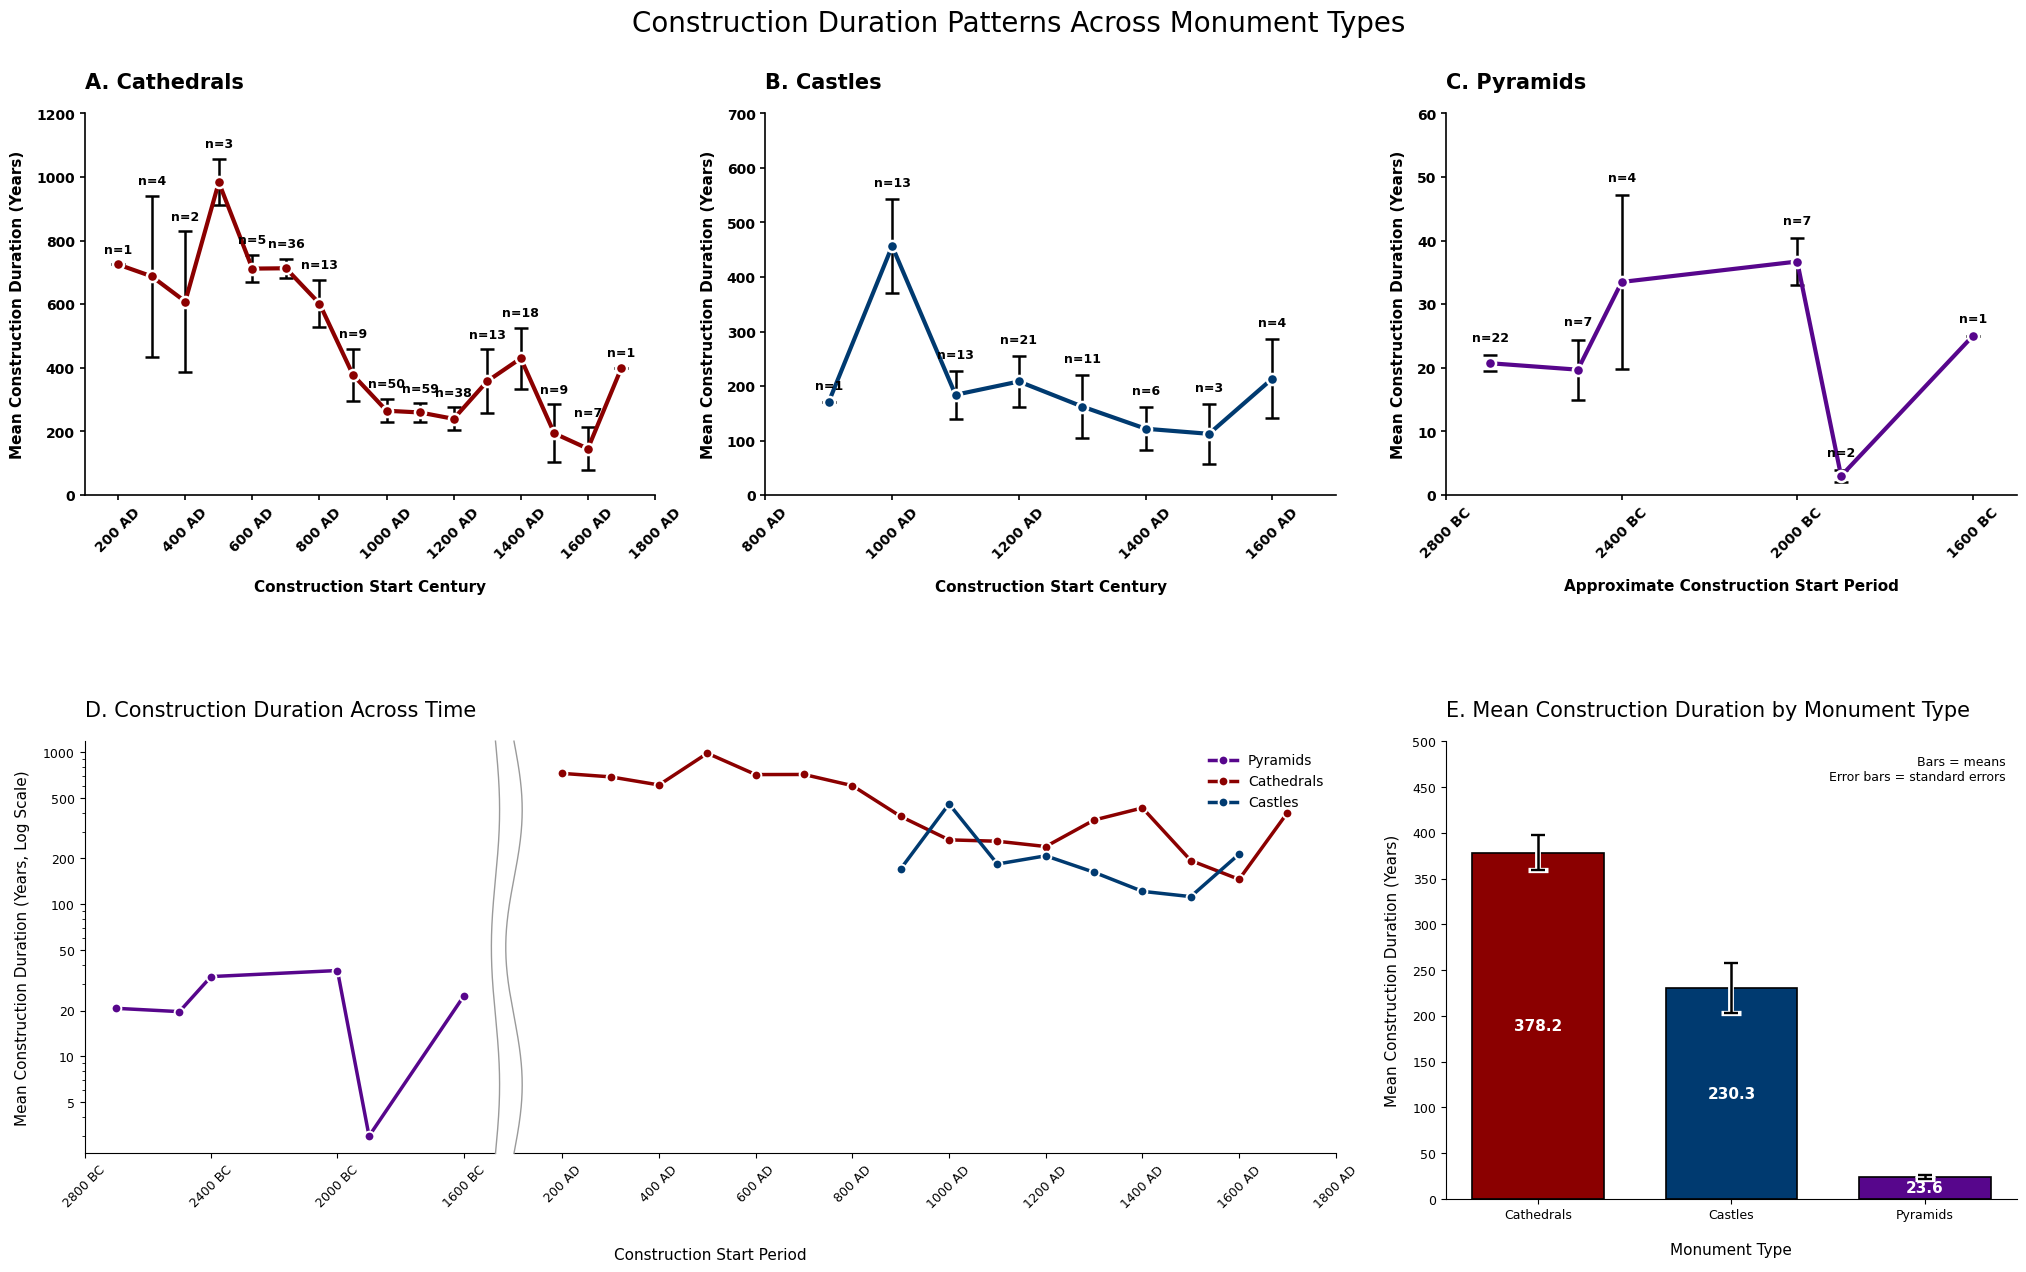


TEMPORAL DURATION SUMMARIES

Cathedrals by 100-year period:
 time_bin  mean_duration  std_duration  count  standard_error
      200     725.000000           NaN      1        0.000000
      300     687.750000    504.480178      4      252.240089
      400     608.500000    311.834091      2      220.500000
      500     983.333333    125.830574      3       72.648316
      600     712.000000     96.091103      5       42.973247
      700     713.083333    178.633763     36       29.772294
      800     602.153846    271.359186     13       75.261497
      900     377.777778    248.062884      9       82.687628
     1000     265.160000    259.765307     50       36.736362
     1100     259.694915    221.252099     59       28.804570
     1200     239.684211    220.207654     38       35.722399
     1300     357.923077    359.956123     13       99.833866
     1400     429.944444    403.722163     18       95.158226
     1500     194.000000    273.563064      9       91.187688
     1600

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import (
    FuncFormatter,
    FixedLocator
)

from matplotlib.gridspec import (
    GridSpec,
    GridSpecFromSubplotSpec
)


# ============================================================
# 1. SETTINGS
# ============================================================

DATA_PATH = (
    "monuments_harmonized_cathedral_castle_"
    "manual_duration_corrected.csv"
)

COLORS = {
    "cathedral": "#8B0000",
    "castle": "#003A70",
    "pyramid": "#57068C"
}

DISPLAY_LABELS = {
    "cathedral": "Cathedrals",
    "castle": "Castles",
    "pyramid": "Pyramids"
}

BAR_ORDER = [
    "cathedral",
    "castle",
    "pyramid"
]

DPI = 300
TIME_BIN_WIDTH = 100

# Wider and slightly taller composite canvas
COMPOSITE_FIG_SIZE = (21, 13)

# Temporal x-axis padding
CATHEDRAL_X_PADDING = 100
CASTLE_X_PADDING = 100
PYRAMID_X_PADDING = 100
COMBINED_X_PADDING = 100

# More space between rows and columns
HSPACE = 0.62
WSPACE = 0.48


# ------------------------------------------------------------
# TOP PANELS A, B, AND C
# ------------------------------------------------------------

TOP_TEMPORAL_LINEWIDTH = 3.0
TOP_TEMPORAL_MARKERSIZE = 8
TOP_TEMPORAL_MARKER_EDGEWIDTH = 1.8

TOP_TEMPORAL_ERROR_LINEWIDTH = 1.8
TOP_TEMPORAL_ERROR_CAPSIZE = 5
TOP_TEMPORAL_ERROR_CAPTHICK = 1.7

TOP_PANEL_TITLE_FONTSIZE = 15
TOP_PANEL_AXIS_FONTSIZE = 11
TOP_PANEL_TICK_FONTSIZE = 10

# Bold sample-size labels for top three panels
N_LABEL_FONTSIZE = 9


# ------------------------------------------------------------
# PANEL D
# ------------------------------------------------------------

COMBINED_LINEWIDTH = 2.5
COMBINED_MARKERSIZE = 7
COMBINED_MARKER_EDGEWIDTH = 1.4

# Relative widths of the two portions of the broken x-axis.
# The pyramid period occupies one-third of Panel D and the
# cathedral/castle period occupies two-thirds.
BROKEN_AXIS_WIDTH_RATIOS = [1, 2]

# Gap between the two parts of the broken x-axis
BROKEN_AXIS_WSPACE = 0.03


# ------------------------------------------------------------
# PANEL E
# ------------------------------------------------------------

BAR_WIDTH = 0.68

# White outline behind bar-chart error bars
WHITE_ERROR_LINEWIDTH = 4.2
WHITE_ERROR_CAPSIZE = 7
WHITE_ERROR_CAPTHICK = 3.8

# Black error bars over white outline
BLACK_ERROR_LINEWIDTH = 1.8
BLACK_ERROR_CAPSIZE = 5
BLACK_ERROR_CAPTHICK = 1.7


# ============================================================
# 2. LOAD AND CLEAN DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

required_columns = [
    "monument_type",
    "start_year",
    "duration_years_harmonized"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        + ", ".join(missing_columns)
    )

df["monument_type"] = (
    df["monument_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["start_year"] = pd.to_numeric(
    df["start_year"],
    errors="coerce"
)

df["duration_years_harmonized"] = pd.to_numeric(
    df["duration_years_harmonized"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "monument_type",
        "start_year",
        "duration_years_harmonized"
    ]
).copy()

df = df[
    df["monument_type"].isin(COLORS.keys())
].copy()

invalid_duration_count = (
    df["duration_years_harmonized"] < 0
).sum()

if invalid_duration_count > 0:
    print(
        f"Removing {invalid_duration_count} record(s) "
        "with negative construction duration."
    )

    df = df[
        df["duration_years_harmonized"] >= 0
    ].copy()

if df.empty:
    raise ValueError(
        "No valid monument records remain after cleaning."
    )


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def clean_axes(ax):
    """Remove unnecessary gridlines and borders."""

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=9
    )


def embolden_top_panel(ax):
    """
    Make text elements in Panels A, B, and C slightly larger
    and bolder without changing Panels D or E.
    """

    # Panel title
    ax.title.set_fontweight("bold")

    # Axis titles
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")

    # Tick labels
    for tick_label in ax.get_xticklabels():
        tick_label.set_fontweight("bold")
        tick_label.set_fontsize(
            TOP_PANEL_TICK_FONTSIZE
        )

    for tick_label in ax.get_yticklabels():
        tick_label.set_fontweight("bold")
        tick_label.set_fontsize(
            TOP_PANEL_TICK_FONTSIZE
        )

    # Thicken the visible axes slightly
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.tick_params(
        axis="both",
        which="major",
        width=1.2
    )


def floor_to_interval(value, interval):
    """Round downward to the nearest interval."""

    return int(
        interval * np.floor(value / interval)
    )


def ceil_to_interval(value, interval):
    """Round upward to the nearest interval."""

    return int(
        interval * np.ceil(value / interval)
    )


def format_historical_year(value, position=None):
    """
    Format negative years as BC and positive years as AD.
    """

    year = int(round(value))

    if year < 0:
        return f"{abs(year)} BC"

    if year > 0:
        return f"{year} AD"

    return "BC/AD"


def format_plain_number(value, position=None):
    """
    Format log-axis tick values as ordinary numbers instead
    of scientific notation.
    """

    if value >= 1:
        return f"{value:g}"

    return f"{value:.1f}"


def assign_time_bins(
    data,
    year_column="start_year",
    bin_width=100
):
    """
    Assign every monument to a regular temporal bin.

    Examples with 100-year bins:
        -2613 -> -2700
        -2494 -> -2500
         1145 -> 1100
    """

    result = data.copy()

    result["time_bin"] = (
        np.floor(
            result[year_column] / bin_width
        ) * bin_width
    ).astype(int)

    return result


def make_temporal_summary(
    data,
    x_column="time_bin",
    duration_column="duration_years_harmonized"
):
    """
    Calculate mean duration, standard deviation, count,
    and standard error within each temporal bin.
    """

    grouped = (
        data.groupby(x_column)[duration_column]
        .agg(
            mean_duration="mean",
            std_duration="std",
            count="count"
        )
        .reset_index()
        .sort_values(x_column)
    )

    grouped["standard_error"] = (
        grouped["std_duration"]
        / np.sqrt(grouped["count"])
    )

    grouped["standard_error"] = (
        grouped["standard_error"]
        .fillna(0)
    )

    return grouped


def make_overall_summary(
    data,
    duration_column="duration_years_harmonized"
):
    """
    Calculate overall class means and standard errors after
    collapsing across temporal bins.
    """

    summary = (
        data.groupby("monument_type")[duration_column]
        .agg(
            count="count",
            mean_duration="mean",
            std_duration="std"
        )
        .reset_index()
    )

    summary["standard_error"] = (
        summary["std_duration"]
        / np.sqrt(summary["count"])
    )

    summary["standard_error"] = (
        summary["standard_error"]
        .fillna(0)
    )

    order_map = {
        monument: index
        for index, monument in enumerate(BAR_ORDER)
    }

    summary["plot_order"] = (
        summary["monument_type"]
        .map(order_map)
    )

    return (
        summary
        .sort_values("plot_order")
        .reset_index(drop=True)
    )


def plot_temporal_with_errorbars(
    ax,
    grouped,
    monument
):
    """
    Plot a temporal mean line with standard-error bars.

    This function is used only for the top three panels and
    therefore uses the thicker top-panel styling.
    """

    ax.errorbar(
        grouped["time_bin"],
        grouped["mean_duration"],
        yerr=grouped["standard_error"],

        fmt="o-",

        color=COLORS[monument],
        linewidth=TOP_TEMPORAL_LINEWIDTH,

        markersize=TOP_TEMPORAL_MARKERSIZE,
        markerfacecolor=COLORS[monument],
        markeredgecolor="white",
        markeredgewidth=TOP_TEMPORAL_MARKER_EDGEWIDTH,

        ecolor="black",
        elinewidth=TOP_TEMPORAL_ERROR_LINEWIDTH,
        capsize=TOP_TEMPORAL_ERROR_CAPSIZE,
        capthick=TOP_TEMPORAL_ERROR_CAPTHICK,

        label=DISPLAY_LABELS[monument],
        zorder=3
    )


def plot_temporal_without_errorbars(
    ax,
    grouped,
    monument
):
    """
    Plot a temporal mean line without uncertainty bars.

    This function is used for Panel D.
    """

    ax.plot(
        grouped["time_bin"],
        grouped["mean_duration"],

        marker="o",

        color=COLORS[monument],
        linewidth=COMBINED_LINEWIDTH,

        markersize=COMBINED_MARKERSIZE,
        markerfacecolor=COLORS[monument],
        markeredgecolor="white",
        markeredgewidth=COMBINED_MARKER_EDGEWIDTH,

        label=DISPLAY_LABELS[monument],
        zorder=3
    )


def add_n_labels(
    ax,
    grouped,
    offset_fraction=0.025,
    fontsize=9
):
    """
    Add bold sample-size labels above temporal points.

    The label is placed above the upper end of the corresponding
    standard-error bar.
    """

    y_minimum, y_maximum = ax.get_ylim()

    offset = (
        y_maximum - y_minimum
    ) * offset_fraction

    for _, row in grouped.iterrows():
        ax.text(
            row["time_bin"],
            row["mean_duration"]
            + row["standard_error"]
            + offset,

            f"n={int(row['count'])}",

            ha="center",
            va="bottom",

            fontsize=fontsize,
            fontweight="bold",
            color="black",

            clip_on=False,
            zorder=5
        )


def set_temporal_x_axis(
    ax,
    grouped,
    tick_spacing,
    padding,
    rotation=45
):
    """
    Set a padded historical x-axis with regular tick locations.
    """

    first_point = grouped["time_bin"].min()
    last_point = grouped["time_bin"].max()

    ax.set_xlim(
        first_point - padding,
        last_point + padding
    )

    tick_start = floor_to_interval(
        first_point,
        tick_spacing
    )

    tick_end = ceil_to_interval(
        last_point,
        tick_spacing
    )

    ticks = np.arange(
        tick_start,
        tick_end + tick_spacing,
        tick_spacing
    )

    ax.xaxis.set_major_locator(
        FixedLocator(ticks)
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(format_historical_year)
    )

    ax.tick_params(
        axis="x",
        rotation=rotation
    )


def set_linear_y_axis(
    ax,
    grouped_list,
    tick_spacing,
    expansion=1.10,
    include_error=True
):
    """
    Set a linear y-axis appropriate for one or more series.
    """

    upper_values = []

    for grouped in grouped_list:

        values = grouped["mean_duration"].copy()

        if include_error:
            values = (
                values
                + grouped["standard_error"]
            )

        upper_values.extend(
            values.tolist()
        )

    highest_value = max(
        upper_values
    )

    y_maximum = (
        np.ceil(
            highest_value
            * expansion
            / tick_spacing
        ) * tick_spacing
    )

    ax.set_ylim(
        0,
        y_maximum
    )

    ax.set_yticks(
        np.arange(
            0,
            y_maximum + tick_spacing,
            tick_spacing
        )
    )


def set_shared_log_y_axis(
    ax_list,
    grouped_list,
    lower_expansion=1.30,
    upper_expansion=1.20
):
    """
    Apply the same logarithmic y-axis limits and ticks to
    multiple axes.

    Logarithmic axes require strictly positive values.
    """

    positive_values = []

    for grouped in grouped_list:

        values = grouped[
            "mean_duration"
        ].to_numpy()

        positive_values.extend(
            values[values > 0].tolist()
        )

    if not positive_values:
        raise ValueError(
            "Panel D cannot use a logarithmic y-axis because "
            "no positive mean-duration values were found."
        )

    lowest_value = min(positive_values)
    highest_value = max(positive_values)

    y_minimum = (
        lowest_value / lower_expansion
    )

    y_maximum = (
        highest_value * upper_expansion
    )

    # Suitable readable tick candidates for these data.
    tick_candidates = np.array([
        1,
        2,
        5,
        10,
        20,
        50,
        100,
        200,
        500,
        1000,
        2000,
        5000
    ], dtype=float)

    tick_values = tick_candidates[
        (tick_candidates >= y_minimum)
        & (tick_candidates <= y_maximum)
    ]

    for ax in ax_list:

        ax.set_yscale("log")

        ax.set_ylim(
            y_minimum,
            y_maximum
        )

        ax.yaxis.set_major_locator(
            FixedLocator(tick_values)
        )

        ax.yaxis.set_major_formatter(
            FuncFormatter(format_plain_number)
        )


def add_full_height_break_marks(
    left_ax,
    right_ax,
    wave_width=0.010,
    wave_count=1.5,
    color="#9A9A9A",
    linewidth=1.0
):
    """
    Draw a narrow, gently swaying full-height broken-axis marker.
    """

    y_values = np.linspace(
        0,
        1,
        400
    )

    wave = (
        wave_width
        * np.sin(
            wave_count
            * 2
            * np.pi
            * y_values
        )
    )

    left_ax.plot(
        1 + wave,
        y_values,

        transform=left_ax.transAxes,

        color=color,
        linewidth=linewidth,

        clip_on=False,
        zorder=10
    )

    right_ax.plot(
        wave,
        y_values,

        transform=right_ax.transAxes,

        color=color,
        linewidth=linewidth,

        clip_on=False,
        zorder=10
    )


# ============================================================
# 4. PREPARE SUMMARIES
# ============================================================

df = assign_time_bins(
    df,
    year_column="start_year",
    bin_width=TIME_BIN_WIDTH
)

temporal_summaries = {}

for monument in COLORS:

    monument_data = df[
        df["monument_type"] == monument
    ].copy()

    if monument_data.empty:
        print(
            f"Warning: no valid records found for {monument}."
        )
        continue

    temporal_summaries[monument] = (
        make_temporal_summary(
            monument_data
        )
    )

required_monuments = [
    "cathedral",
    "castle",
    "pyramid"
]

missing_monuments = [
    monument
    for monument in required_monuments
    if monument not in temporal_summaries
]

if missing_monuments:
    raise ValueError(
        "Missing monument data for: "
        + ", ".join(missing_monuments)
    )

cathedral_grouped = (
    temporal_summaries["cathedral"]
)

castle_grouped = (
    temporal_summaries["castle"]
)

pyramid_grouped = (
    temporal_summaries["pyramid"]
)

overall_summary = (
    make_overall_summary(df)
)


# ============================================================
# 5. CREATE COMPOSITE LAYOUT
#
# Top row:
# A cathedral | B castle | C pyramid
#
# Bottom row:
# D combined broken-axis graph: 2/3 width
# E overall bars: 1/3 width
# ============================================================

fig = plt.figure(
    figsize=COMPOSITE_FIG_SIZE
)

gs = GridSpec(
    nrows=2,
    ncols=6,
    figure=fig,

    height_ratios=[
        1.0,
        1.08
    ],

    hspace=HSPACE,
    wspace=WSPACE
)


# ------------------------------------------------------------
# Three equal-width top panels
# ------------------------------------------------------------

ax_cathedral = fig.add_subplot(
    gs[0, 0:2]
)

ax_castle = fig.add_subplot(
    gs[0, 2:4]
)

ax_pyramid = fig.add_subplot(
    gs[0, 4:6]
)


# ------------------------------------------------------------
# Bottom-left Panel D occupies four of the six columns,
# making it two-thirds of the bottom row.
#
# Panel D itself contains two adjacent axes to produce
# the broken historical x-axis.
# ------------------------------------------------------------

combined_subgrid = GridSpecFromSubplotSpec(
    nrows=1,
    ncols=2,

    subplot_spec=gs[1, 0:4],

    width_ratios=BROKEN_AXIS_WIDTH_RATIOS,
    wspace=BROKEN_AXIS_WSPACE
)

ax_combined_left = fig.add_subplot(
    combined_subgrid[0, 0]
)

ax_combined_right = fig.add_subplot(
    combined_subgrid[0, 1],
    sharey=ax_combined_left
)


# ------------------------------------------------------------
# Bottom-right Panel E occupies two of the six columns,
# making it one-third of the bottom row.
# ------------------------------------------------------------

ax_bars = fig.add_subplot(
    gs[1, 4:6]
)


# ============================================================
# 6. PANEL A: CATHEDRALS
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    monument="cathedral"
)

set_temporal_x_axis(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    tick_spacing=200,
    padding=CATHEDRAL_X_PADDING
)

set_linear_y_axis(
    ax=ax_cathedral,
    grouped_list=[
        cathedral_grouped
    ],
    tick_spacing=200,
    expansion=1.10,
    include_error=True
)

add_n_labels(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    offset_fraction=0.022,
    fontsize=N_LABEL_FONTSIZE
)

ax_cathedral.set_title(
    "A. Cathedrals",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_cathedral.set_xlabel(
    "Construction Start Century",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_cathedral.set_ylabel(
    "Mean Construction Duration (Years)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_cathedral
)

embolden_top_panel(
    ax_cathedral
)


# ============================================================
# 7. PANEL B: CASTLES
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_castle,
    grouped=castle_grouped,
    monument="castle"
)

set_temporal_x_axis(
    ax=ax_castle,
    grouped=castle_grouped,
    tick_spacing=200,
    padding=CASTLE_X_PADDING
)

set_linear_y_axis(
    ax=ax_castle,
    grouped_list=[
        castle_grouped
    ],
    tick_spacing=100,
    expansion=1.12,
    include_error=True
)

add_n_labels(
    ax=ax_castle,
    grouped=castle_grouped,
    offset_fraction=0.025,
    fontsize=N_LABEL_FONTSIZE
)

ax_castle.set_title(
    "B. Castles",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_castle.set_xlabel(
    "Construction Start Century",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_castle.set_ylabel(
    "Mean Construction Duration (Years)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_castle
)

embolden_top_panel(
    ax_castle
)


# ============================================================
# 8. PANEL C: PYRAMIDS
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    monument="pyramid"
)

set_temporal_x_axis(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    tick_spacing=400,
    padding=PYRAMID_X_PADDING
)

set_linear_y_axis(
    ax=ax_pyramid,
    grouped_list=[
        pyramid_grouped
    ],
    tick_spacing=10,
    expansion=1.15,
    include_error=True
)

add_n_labels(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    offset_fraction=0.028,
    fontsize=N_LABEL_FONTSIZE
)

ax_pyramid.set_title(
    "C. Pyramids",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_pyramid.set_xlabel(
    "Approximate Construction Start Period",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_pyramid.set_ylabel(
    "Mean Construction Duration (Years)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_pyramid
)

embolden_top_panel(
    ax_pyramid
)


# ============================================================
# 9. PANEL D: ALL THREE MONUMENT TYPES
#
# LEFT SECTION:
# Pyramids during the BC period
#
# RIGHT SECTION:
# Cathedrals and castles during the AD period
#
# BROKEN X-AXIS
# LOGARITHMIC Y-AXIS
# NO ERROR BARS
# ============================================================


# ------------------------------------------------------------
# Left segment: pyramids
# ------------------------------------------------------------

plot_temporal_without_errorbars(
    ax=ax_combined_left,
    grouped=pyramid_grouped,
    monument="pyramid"
)


# ------------------------------------------------------------
# Right segment: cathedrals and castles
# ------------------------------------------------------------

plot_temporal_without_errorbars(
    ax=ax_combined_right,
    grouped=cathedral_grouped,
    monument="cathedral"
)

plot_temporal_without_errorbars(
    ax=ax_combined_right,
    grouped=castle_grouped,
    monument="castle"
)


# ------------------------------------------------------------
# Left historical x-axis for pyramids
# ------------------------------------------------------------

set_temporal_x_axis(
    ax=ax_combined_left,
    grouped=pyramid_grouped,
    tick_spacing=400,
    padding=PYRAMID_X_PADDING
)


# ------------------------------------------------------------
# Right historical x-axis for cathedrals and castles
# ------------------------------------------------------------

combined_first_point = min(
    cathedral_grouped["time_bin"].min(),
    castle_grouped["time_bin"].min()
)

combined_last_point = max(
    cathedral_grouped["time_bin"].max(),
    castle_grouped["time_bin"].max()
)

ax_combined_right.set_xlim(
    combined_first_point - COMBINED_X_PADDING,
    combined_last_point + COMBINED_X_PADDING
)

combined_tick_start = floor_to_interval(
    combined_first_point,
    200
)

combined_tick_end = ceil_to_interval(
    combined_last_point,
    200
)

combined_ticks = np.arange(
    combined_tick_start,
    combined_tick_end + 200,
    200
)

ax_combined_right.xaxis.set_major_locator(
    FixedLocator(combined_ticks)
)

ax_combined_right.xaxis.set_major_formatter(
    FuncFormatter(format_historical_year)
)

ax_combined_right.tick_params(
    axis="x",
    rotation=45
)


# ------------------------------------------------------------
# Shared logarithmic y-axis
# ------------------------------------------------------------

set_shared_log_y_axis(
    ax_list=[
        ax_combined_left,
        ax_combined_right
    ],
    grouped_list=[
        pyramid_grouped,
        cathedral_grouped,
        castle_grouped
    ]
)


# ------------------------------------------------------------
# Panel title and y-axis title
# ------------------------------------------------------------

ax_combined_left.set_title(
    "D. Construction Duration Across Time",
    fontsize=15,
    pad=18,
    loc="left"
)

ax_combined_left.set_ylabel(
    "Mean Construction Duration (Years, Log Scale)",
    fontsize=11,
    labelpad=9
)


# ------------------------------------------------------------
# Legends collected from both halves
# ------------------------------------------------------------

left_handles, left_labels = (
    ax_combined_left.get_legend_handles_labels()
)

right_handles, right_labels = (
    ax_combined_right.get_legend_handles_labels()
)

combined_handles = (
    left_handles
    + right_handles
)

combined_labels = (
    left_labels
    + right_labels
)

ax_combined_right.legend(
    combined_handles,
    combined_labels,

    frameon=False,
    fontsize=10,
    loc="upper right"
)


# ------------------------------------------------------------
# Basic axis cleanup
# ------------------------------------------------------------

clean_axes(
    ax_combined_left
)

clean_axes(
    ax_combined_right
)


# ------------------------------------------------------------
# Remove the touching inner spines
# ------------------------------------------------------------

ax_combined_left.spines[
    "right"
].set_visible(False)

ax_combined_right.spines[
    "left"
].set_visible(False)


# ------------------------------------------------------------
# Only show y-axis labels on the left portion
# ------------------------------------------------------------

ax_combined_right.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False
)


# ------------------------------------------------------------
# Add full-height broken-axis indicators
# ------------------------------------------------------------

add_full_height_break_marks(
    left_ax=ax_combined_left,
    right_ax=ax_combined_right,

    wave_width=0.010,
    wave_count=1.5,
    color="#9A9A9A",
    linewidth=1.0
)


# ============================================================
# 10. PANEL E: OVERALL MEAN BAR CHART
# ============================================================

x_positions = np.arange(
    len(overall_summary)
)

bar_colors = [
    COLORS[monument]
    for monument in overall_summary["monument_type"]
]

bars = ax_bars.bar(
    x_positions,
    overall_summary["mean_duration"],

    width=BAR_WIDTH,

    color=bar_colors,
    edgecolor="black",
    linewidth=1.2,

    zorder=2
)


# ------------------------------------------------------------
# White outline beneath error bars
# ------------------------------------------------------------

ax_bars.errorbar(
    x_positions,
    overall_summary["mean_duration"],
    yerr=overall_summary["standard_error"],

    fmt="none",

    ecolor="white",
    elinewidth=WHITE_ERROR_LINEWIDTH,
    capsize=WHITE_ERROR_CAPSIZE,
    capthick=WHITE_ERROR_CAPTHICK,

    zorder=3
)


# ------------------------------------------------------------
# Black error bars
# ------------------------------------------------------------

ax_bars.errorbar(
    x_positions,
    overall_summary["mean_duration"],
    yerr=overall_summary["standard_error"],

    fmt="none",

    ecolor="black",
    elinewidth=BLACK_ERROR_LINEWIDTH,
    capsize=BLACK_ERROR_CAPSIZE,
    capthick=BLACK_ERROR_CAPTHICK,

    zorder=4
)


# ------------------------------------------------------------
# Mean labels inside bars
# ------------------------------------------------------------

for position, row in zip(
    x_positions,
    overall_summary.itertuples(index=False)
):
    ax_bars.text(
        position,
        row.mean_duration * 0.50,

        f"{row.mean_duration:.1f}",

        ha="center",
        va="center",

        fontsize=11,
        fontweight="bold",
        color="white",

        zorder=5
    )


ax_bars.set_xticks(
    x_positions
)

ax_bars.set_xticklabels([
    DISPLAY_LABELS[monument]
    for monument in overall_summary["monument_type"]
])

maximum_bar_extent = (
    overall_summary["mean_duration"]
    + overall_summary["standard_error"]
).max()

bar_y_maximum = (
    np.ceil(
        maximum_bar_extent
        * 1.18
        / 50
    ) * 50
)

ax_bars.set_ylim(
    0,
    bar_y_maximum
)

ax_bars.set_yticks(
    np.arange(
        0,
        bar_y_maximum + 1,
        50
    )
)

ax_bars.set_title(
    "E. Mean Construction Duration by Monument Type",
    fontsize=15,
    pad=18,
    loc="left"
)

ax_bars.set_xlabel(
    "Monument Type",
    fontsize=11,
    labelpad=15
)

ax_bars.set_ylabel(
    "Mean Construction Duration (Years)",
    fontsize=11,
    labelpad=9
)

ax_bars.text(
    0.98,
    0.97,

    "Bars = means\nError bars = standard errors",

    transform=ax_bars.transAxes,

    ha="right",
    va="top",

    fontsize=9
)

clean_axes(
    ax_bars
)


# ============================================================
# 11. FINAL LAYOUT
# ============================================================

fig.suptitle(
    "Construction Duration Patterns Across Monument Types",
    fontsize=20,
    y=0.975
)

fig.subplots_adjust(
    left=0.055,
    right=0.975,
    bottom=0.095,
    top=0.895,
    hspace=HSPACE,
    wspace=WSPACE
)


# ------------------------------------------------------------
# Center a single x-axis title beneath both portions of Panel D
# ------------------------------------------------------------

combined_left_position = (
    ax_combined_left.get_position()
)

combined_right_position = (
    ax_combined_right.get_position()
)

combined_center_x = (
    combined_left_position.x0
    + combined_right_position.x1
) / 2

combined_xlabel_y = (
    min(
        combined_left_position.y0,
        combined_right_position.y0
    )
    - 0.072
)

fig.text(
    combined_center_x,
    combined_xlabel_y,

    "Construction Start Period",

    ha="center",
    va="top",

    fontsize=11
)


# ------------------------------------------------------------
# Extend Panel E downward
#
# Panel D has rotated historical labels and therefore extends
# farther visually below its plotting area. Panel E is expanded
# downward to produce a closer overall visual match.
# ------------------------------------------------------------

panel_e_position = (
    ax_bars.get_position()
)

panel_e_downward_extension = 0.035

ax_bars.set_position([
    panel_e_position.x0,
    panel_e_position.y0
    - panel_e_downward_extension,

    panel_e_position.width,

    panel_e_position.height
    + panel_e_downward_extension
])


# ============================================================
# 12. SAVE AND DISPLAY
# ============================================================

composite_figure_path = (
    "construction_duration_alternative_"
    "five_panel_broken_axis_log_scale.png"
)

fig.savefig(
    composite_figure_path,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ============================================================
# 13. PRINT SUMMARIES
# ============================================================

print("\n" + "=" * 70)
print("TEMPORAL DURATION SUMMARIES")
print("=" * 70)

for monument in [
    "cathedral",
    "castle",
    "pyramid"
]:

    print(
        f"\n{DISPLAY_LABELS[monument]} "
        f"by {TIME_BIN_WIDTH}-year period:"
    )

    print(
        temporal_summaries[
            monument
        ].to_string(index=False)
    )


print("\n" + "=" * 70)
print("OVERALL DURATION SUMMARY")
print("=" * 70)

print(
    overall_summary[
        [
            "monument_type",
            "count",
            "mean_duration",
            "std_duration",
            "standard_error"
        ]
    ].to_string(index=False)
)

print("\nSaved figure:")
print(composite_figure_path)

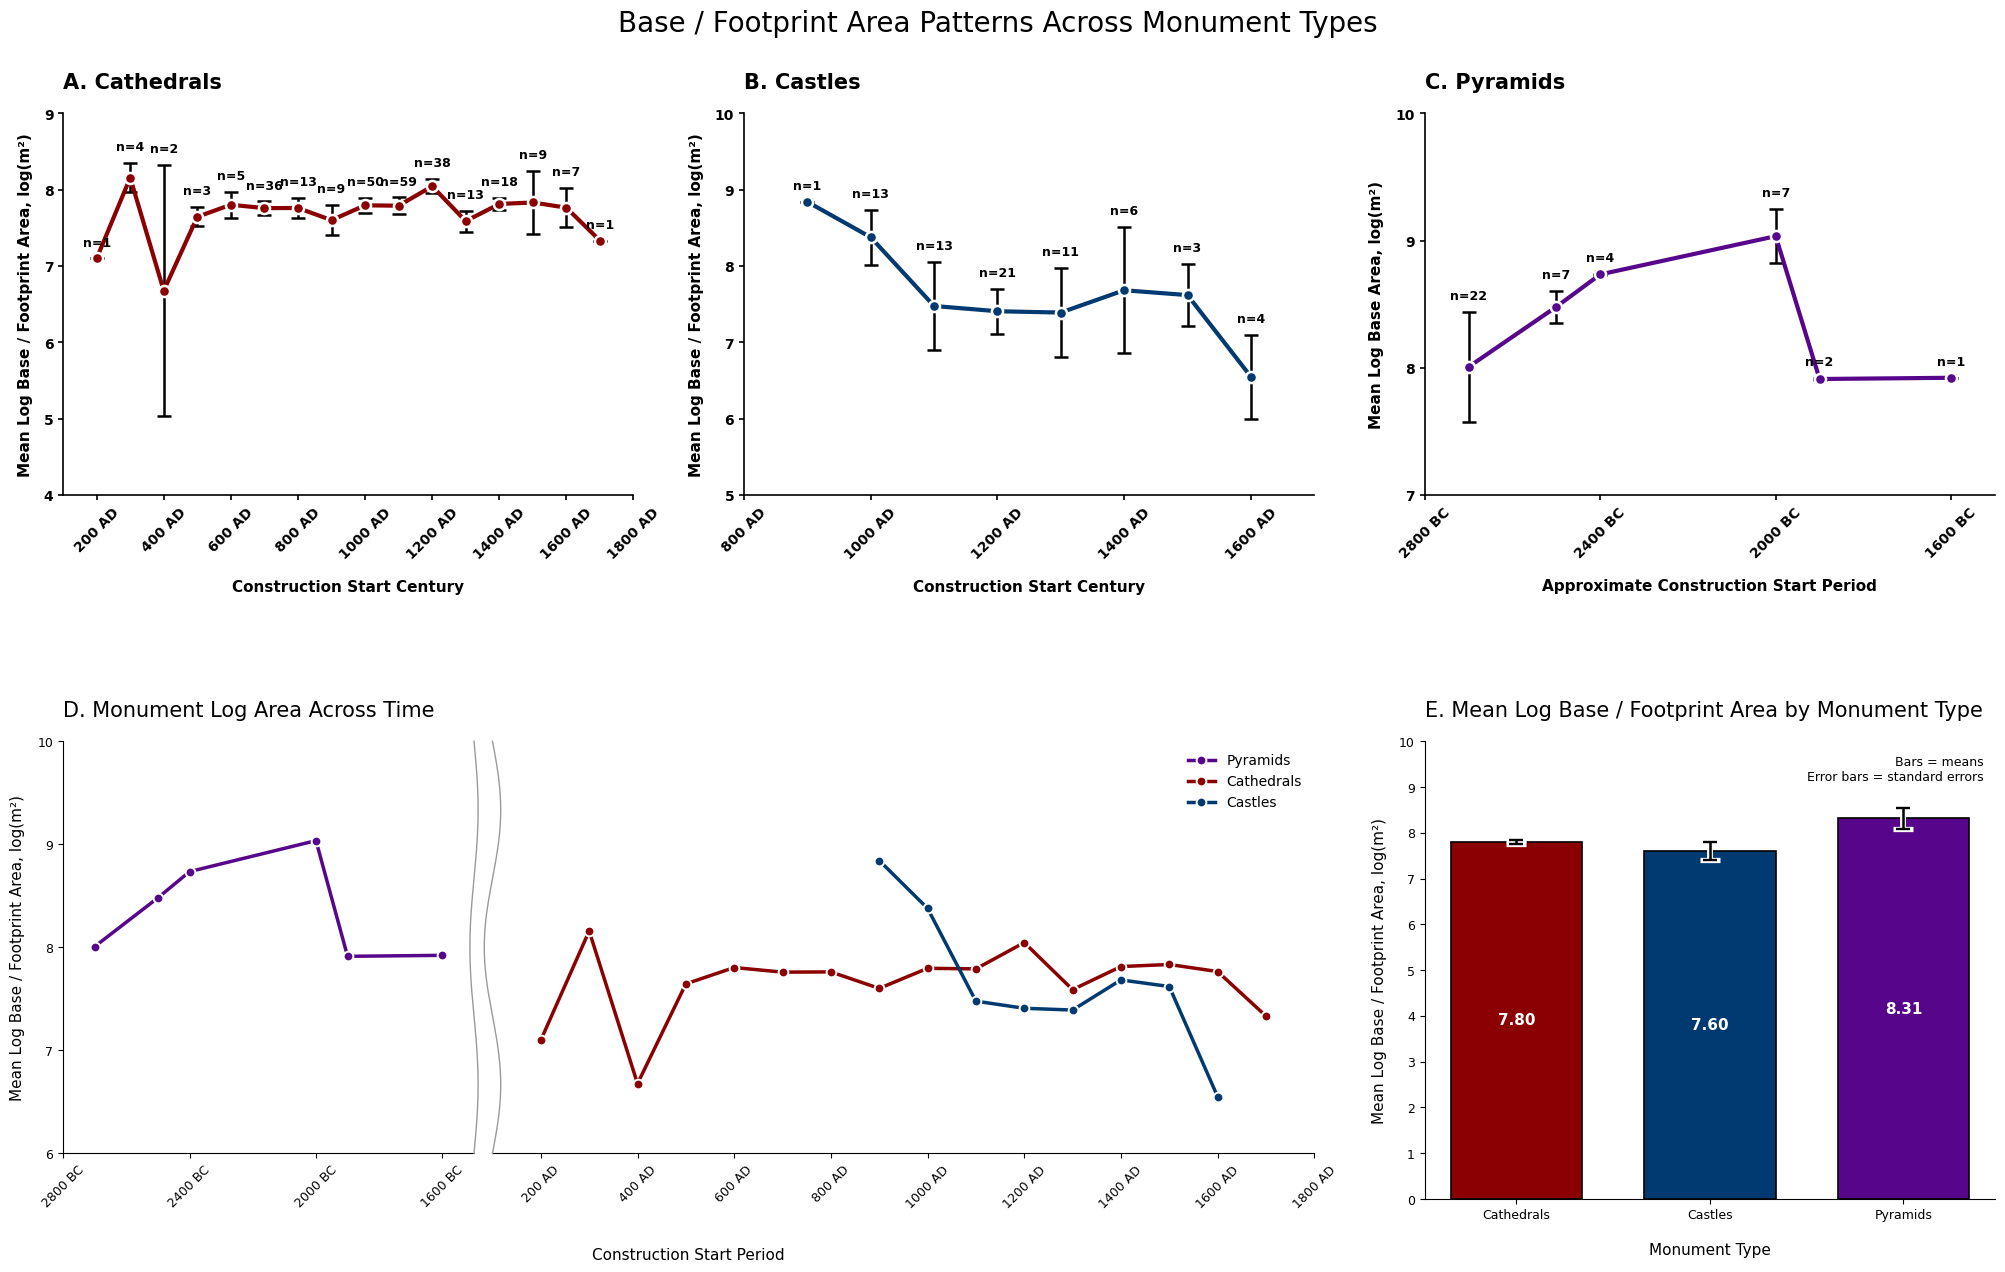


TEMPORAL LOG-AREA SUMMARIES

Cathedrals by 100-year period:
 time_bin  mean_log_area  std_log_area  count  standard_error
      200       7.099249           NaN      1        0.000000
      300       8.158067      0.380066      4        0.190033
      400       6.676992      2.321897      2        1.641829
      500       7.645074      0.217856      3        0.125779
      600       7.803662      0.384643      5        0.172018
      700       7.758881      0.526280     36        0.087713
      800       7.761155      0.460233     13        0.127646
      900       7.601177      0.584893      9        0.194964
     1000       7.796019      0.718683     50        0.101637
     1100       7.790679      0.830210     59        0.108084
     1200       8.045789      0.576860     38        0.093579
     1300       7.589025      0.493931     13        0.136992
     1400       7.813127      0.356741     18        0.084085
     1500       7.833147      1.231682      9        0.410561
     1600

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


# ============================================================
# 1. SETTINGS
# ============================================================

DATA_PATH = (
    "monuments_harmonized_cathedral_castle_"
    "manual_duration_corrected.csv"
)

COLORS = {
    "cathedral": "#8B0000",
    "castle": "#003A70",
    "pyramid": "#57068C"
}

DISPLAY_LABELS = {
    "cathedral": "Cathedrals",
    "castle": "Castles",
    "pyramid": "Pyramids"
}

BAR_ORDER = [
    "cathedral",
    "castle",
    "pyramid"
]

DPI = 300
TIME_BIN_WIDTH = 100

# Wide five-panel composite
COMPOSITE_FIG_SIZE = (21, 13)

# Temporal x-axis padding
CATHEDRAL_X_PADDING = 100
CASTLE_X_PADDING = 100
PYRAMID_X_PADDING = 100
COMBINED_X_PADDING = 100

# Layout spacing
HSPACE = 0.62
WSPACE = 0.48


# ------------------------------------------------------------
# TOP PANELS A, B, AND C
# ------------------------------------------------------------

TOP_TEMPORAL_LINEWIDTH = 3.0
TOP_TEMPORAL_MARKERSIZE = 8
TOP_TEMPORAL_MARKER_EDGEWIDTH = 1.8

TOP_TEMPORAL_ERROR_LINEWIDTH = 1.8
TOP_TEMPORAL_ERROR_CAPSIZE = 5
TOP_TEMPORAL_ERROR_CAPTHICK = 1.7

TOP_PANEL_TITLE_FONTSIZE = 15
TOP_PANEL_AXIS_FONTSIZE = 11
TOP_PANEL_TICK_FONTSIZE = 10

N_LABEL_FONTSIZE = 9


# ------------------------------------------------------------
# PANEL D
# ------------------------------------------------------------

COMBINED_LINEWIDTH = 2.5
COMBINED_MARKERSIZE = 7
COMBINED_MARKER_EDGEWIDTH = 1.4

# Relative widths of the two portions of the broken x-axis.
# The pyramid period occupies one-third of Panel D and the
# cathedral/castle period occupies two-thirds.
BROKEN_AXIS_WIDTH_RATIOS = [1, 2]

# Narrow gap between the two parts of the broken x-axis
BROKEN_AXIS_WSPACE = 0.03


# ------------------------------------------------------------
# PANEL E
# ------------------------------------------------------------

BAR_WIDTH = 0.68

WHITE_ERROR_LINEWIDTH = 4.2
WHITE_ERROR_CAPSIZE = 7
WHITE_ERROR_CAPTHICK = 3.8

BLACK_ERROR_LINEWIDTH = 1.8
BLACK_ERROR_CAPSIZE = 5
BLACK_ERROR_CAPTHICK = 1.7


# ============================================================
# 2. LOAD AND CLEAN DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

required_columns = [
    "monument_type",
    "start_year",
    "area_m2"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        + ", ".join(missing_columns)
    )

df["monument_type"] = (
    df["monument_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["start_year"] = pd.to_numeric(
    df["start_year"],
    errors="coerce"
)

df["area_m2"] = pd.to_numeric(
    df["area_m2"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "monument_type",
        "start_year",
        "area_m2"
    ]
).copy()

df = df[
    df["monument_type"].isin(COLORS.keys())
].copy()

# Physical area must be positive before log transformation
invalid_area_count = (
    df["area_m2"] <= 0
).sum()

if invalid_area_count > 0:
    print(
        f"Removing {invalid_area_count} record(s) "
        "with non-positive area."
    )

    df = df[
        df["area_m2"] > 0
    ].copy()

if df.empty:
    raise ValueError(
        "No valid monument records remain after cleaning."
    )

# Natural-log transformation
df["log_area_m2"] = np.log1p(
    df["area_m2"]
)


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def clean_axes(ax):
    """Remove unnecessary gridlines and borders."""

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=9
    )


def embolden_top_panel(ax):
    """Make Panels A, B, and C visually heavier."""

    ax.title.set_fontweight("bold")

    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")

    for tick_label in ax.get_xticklabels():
        tick_label.set_fontweight("bold")
        tick_label.set_fontsize(
            TOP_PANEL_TICK_FONTSIZE
        )

    for tick_label in ax.get_yticklabels():
        tick_label.set_fontweight("bold")
        tick_label.set_fontsize(
            TOP_PANEL_TICK_FONTSIZE
        )

    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.tick_params(
        axis="both",
        which="major",
        width=1.2
    )


def floor_to_interval(value, interval):
    """Round downward to the nearest interval."""

    return int(
        interval * np.floor(value / interval)
    )


def ceil_to_interval(value, interval):
    """Round upward to the nearest interval."""

    return int(
        interval * np.ceil(value / interval)
    )


def format_historical_year(value, position=None):
    """Format negative years as BC and positive years as AD."""

    year = int(round(value))

    if year < 0:
        return f"{abs(year)} BC"

    if year > 0:
        return f"{year} AD"

    return "BC/AD"


def assign_time_bins(
    data,
    year_column="start_year",
    bin_width=100
):
    """Assign every monument to a regular temporal bin."""

    result = data.copy()

    result["time_bin"] = (
        np.floor(
            result[year_column] / bin_width
        ) * bin_width
    ).astype(int)

    return result


def make_temporal_summary(
    data,
    x_column="time_bin",
    area_column="log_area_m2"
):
    """
    Calculate mean log area, standard deviation, count,
    and standard error within each temporal bin.
    """

    grouped = (
        data.groupby(x_column)[area_column]
        .agg(
            mean_log_area="mean",
            std_log_area="std",
            count="count"
        )
        .reset_index()
        .sort_values(x_column)
    )

    grouped["standard_error"] = (
        grouped["std_log_area"]
        / np.sqrt(grouped["count"])
    )

    grouped["standard_error"] = (
        grouped["standard_error"]
        .fillna(0)
    )

    return grouped


def make_overall_summary(
    data,
    area_column="log_area_m2"
):
    """
    Calculate overall mean log area and standard error for each
    monument type.
    """

    summary = (
        data.groupby("monument_type")[area_column]
        .agg(
            count="count",
            mean_log_area="mean",
            std_log_area="std"
        )
        .reset_index()
    )

    summary["standard_error"] = (
        summary["std_log_area"]
        / np.sqrt(summary["count"])
    )

    summary["standard_error"] = (
        summary["standard_error"]
        .fillna(0)
    )

    order_map = {
        monument: index
        for index, monument in enumerate(BAR_ORDER)
    }

    summary["plot_order"] = (
        summary["monument_type"]
        .map(order_map)
    )

    return (
        summary
        .sort_values("plot_order")
        .reset_index(drop=True)
    )


def plot_temporal_with_errorbars(
    ax,
    grouped,
    monument
):
    """Plot temporal mean log area with standard-error bars."""

    ax.errorbar(
        grouped["time_bin"],
        grouped["mean_log_area"],
        yerr=grouped["standard_error"],

        fmt="o-",

        color=COLORS[monument],
        linewidth=TOP_TEMPORAL_LINEWIDTH,

        markersize=TOP_TEMPORAL_MARKERSIZE,
        markerfacecolor=COLORS[monument],
        markeredgecolor="white",
        markeredgewidth=TOP_TEMPORAL_MARKER_EDGEWIDTH,

        ecolor="black",
        elinewidth=TOP_TEMPORAL_ERROR_LINEWIDTH,
        capsize=TOP_TEMPORAL_ERROR_CAPSIZE,
        capthick=TOP_TEMPORAL_ERROR_CAPTHICK,

        label=DISPLAY_LABELS[monument],
        zorder=3
    )


def plot_temporal_without_errorbars(
    ax,
    grouped,
    monument
):
    """Plot temporal mean log area without error bars."""

    ax.plot(
        grouped["time_bin"],
        grouped["mean_log_area"],

        marker="o",

        color=COLORS[monument],
        linewidth=COMBINED_LINEWIDTH,

        markersize=COMBINED_MARKERSIZE,
        markerfacecolor=COLORS[monument],
        markeredgecolor="white",
        markeredgewidth=COMBINED_MARKER_EDGEWIDTH,

        label=DISPLAY_LABELS[monument],
        zorder=3
    )


def add_n_labels(
    ax,
    grouped,
    offset_fraction=0.025,
    fontsize=9
):
    """Add bold sample-size labels above error bars."""

    y_minimum, y_maximum = ax.get_ylim()

    offset = (
        y_maximum - y_minimum
    ) * offset_fraction

    for _, row in grouped.iterrows():
        ax.text(
            row["time_bin"],
            row["mean_log_area"]
            + row["standard_error"]
            + offset,

            f"n={int(row['count'])}",

            ha="center",
            va="bottom",

            fontsize=fontsize,
            fontweight="bold",
            color="black",

            clip_on=False,
            zorder=5
        )


def set_temporal_x_axis(
    ax,
    grouped,
    tick_spacing,
    padding,
    rotation=45
):
    """Set a padded historical x-axis."""

    first_point = grouped["time_bin"].min()
    last_point = grouped["time_bin"].max()

    ax.set_xlim(
        first_point - padding,
        last_point + padding
    )

    tick_start = floor_to_interval(
        first_point,
        tick_spacing
    )

    tick_end = ceil_to_interval(
        last_point,
        tick_spacing
    )

    ticks = np.arange(
        tick_start,
        tick_end + tick_spacing,
        tick_spacing
    )

    ax.xaxis.set_major_locator(
        FixedLocator(ticks)
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(format_historical_year)
    )

    ax.tick_params(
        axis="x",
        rotation=rotation
    )


def set_linear_y_axis(
    ax,
    grouped_list,
    tick_spacing=1.0,
    expansion=1.10,
    include_error=True
):
    """Set a linear y-axis for one or more log-area series."""

    lower_values = []
    upper_values = []

    for grouped in grouped_list:

        means = grouped["mean_log_area"].copy()

        if include_error:
            lower = means - grouped["standard_error"]
            upper = means + grouped["standard_error"]
        else:
            lower = means
            upper = means

        lower_values.extend(
            lower.tolist()
        )

        upper_values.extend(
            upper.tolist()
        )

    lowest_value = min(
        lower_values
    )

    highest_value = max(
        upper_values
    )

    value_range = max(
        highest_value - lowest_value,
        tick_spacing
    )

    y_minimum = (
        np.floor(
            (
                lowest_value
                - value_range * 0.08
            )
            / tick_spacing
        )
        * tick_spacing
    )

    y_maximum = (
        np.ceil(
            (
                highest_value
                + value_range * (expansion - 1)
            )
            / tick_spacing
        )
        * tick_spacing
    )

    ax.set_ylim(
        y_minimum,
        y_maximum
    )

    ax.set_yticks(
        np.arange(
            y_minimum,
            y_maximum + tick_spacing,
            tick_spacing
        )
    )


def add_full_height_break_marks(
    left_ax,
    right_ax,
    wave_width=0.010,
    wave_count=1.5,
    color="#9A9A9A",
    linewidth=1.0
):
    """
    Draw a narrow, gently swaying full-height broken-axis marker.
    """

    y_values = np.linspace(
        0,
        1,
        400
    )

    wave = (
        wave_width
        * np.sin(
            wave_count
            * 2
            * np.pi
            * y_values
        )
    )

    left_ax.plot(
        1 + wave,
        y_values,

        transform=left_ax.transAxes,

        color=color,
        linewidth=linewidth,

        clip_on=False,
        zorder=10
    )

    right_ax.plot(
        wave,
        y_values,

        transform=right_ax.transAxes,

        color=color,
        linewidth=linewidth,

        clip_on=False,
        zorder=10
    )


# ============================================================
# 4. PREPARE SUMMARIES
# ============================================================

df = assign_time_bins(
    df,
    year_column="start_year",
    bin_width=TIME_BIN_WIDTH
)

temporal_summaries = {}

for monument in COLORS:

    monument_data = df[
        df["monument_type"] == monument
    ].copy()

    if monument_data.empty:
        print(
            f"Warning: no valid records found for {monument}."
        )
        continue

    temporal_summaries[monument] = (
        make_temporal_summary(
            monument_data
        )
    )

required_monuments = [
    "cathedral",
    "castle",
    "pyramid"
]

missing_monuments = [
    monument
    for monument in required_monuments
    if monument not in temporal_summaries
]

if missing_monuments:
    raise ValueError(
        "Missing monument data for: "
        + ", ".join(missing_monuments)
    )

cathedral_grouped = (
    temporal_summaries["cathedral"]
)

castle_grouped = (
    temporal_summaries["castle"]
)

pyramid_grouped = (
    temporal_summaries["pyramid"]
)

overall_summary = (
    make_overall_summary(df)
)


# ============================================================
# 5. CREATE COMPOSITE LAYOUT
#
# Top row:
# A cathedral | B castle | C pyramid
#
# Bottom row:
# D combined cathedral/castle | E overall means
# ============================================================

fig = plt.figure(
    figsize=COMPOSITE_FIG_SIZE
)

gs = GridSpec(
    nrows=2,
    ncols=6,
    figure=fig,

    height_ratios=[
        1.0,
        1.08
    ],

    hspace=HSPACE,
    wspace=WSPACE
)

ax_cathedral = fig.add_subplot(
    gs[0, 0:2]
)

ax_castle = fig.add_subplot(
    gs[0, 2:4]
)

ax_pyramid = fig.add_subplot(
    gs[0, 4:6]
)

# Bottom-left Panel D occupies four of the six columns,
# making it two-thirds of the bottom row.
#
# Panel D contains two adjacent axes to create the broken
# historical x-axis.
combined_subgrid = GridSpecFromSubplotSpec(
    nrows=1,
    ncols=2,

    subplot_spec=gs[1, 0:4],

    width_ratios=BROKEN_AXIS_WIDTH_RATIOS,
    wspace=BROKEN_AXIS_WSPACE
)

ax_combined_left = fig.add_subplot(
    combined_subgrid[0, 0]
)

ax_combined_right = fig.add_subplot(
    combined_subgrid[0, 1],
    sharey=ax_combined_left
)

# Bottom-right Panel E occupies one-third of the bottom row.
ax_bars = fig.add_subplot(
    gs[1, 4:6]
)


# ============================================================
# 6. PANEL A: CATHEDRALS
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    monument="cathedral"
)

set_temporal_x_axis(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    tick_spacing=200,
    padding=CATHEDRAL_X_PADDING
)

set_linear_y_axis(
    ax=ax_cathedral,
    grouped_list=[
        cathedral_grouped
    ],
    tick_spacing=1.0,
    expansion=1.16,
    include_error=True
)

add_n_labels(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    offset_fraction=0.025,
    fontsize=N_LABEL_FONTSIZE
)

ax_cathedral.set_title(
    "A. Cathedrals",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_cathedral.set_xlabel(
    "Construction Start Century",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_cathedral.set_ylabel(
    "Mean Log Base / Footprint Area, log(m²)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_cathedral
)

embolden_top_panel(
    ax_cathedral
)


# ============================================================
# 7. PANEL B: CASTLES
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_castle,
    grouped=castle_grouped,
    monument="castle"
)

set_temporal_x_axis(
    ax=ax_castle,
    grouped=castle_grouped,
    tick_spacing=200,
    padding=CASTLE_X_PADDING
)

set_linear_y_axis(
    ax=ax_castle,
    grouped_list=[
        castle_grouped
    ],
    tick_spacing=1.0,
    expansion=1.16,
    include_error=True
)

add_n_labels(
    ax=ax_castle,
    grouped=castle_grouped,
    offset_fraction=0.025,
    fontsize=N_LABEL_FONTSIZE
)

ax_castle.set_title(
    "B. Castles",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_castle.set_xlabel(
    "Construction Start Century",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_castle.set_ylabel(
    "Mean Log Base / Footprint Area, log(m²)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_castle
)

embolden_top_panel(
    ax_castle
)


# ============================================================
# 8. PANEL C: PYRAMIDS
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    monument="pyramid"
)

set_temporal_x_axis(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    tick_spacing=400,
    padding=PYRAMID_X_PADDING
)

set_linear_y_axis(
    ax=ax_pyramid,
    grouped_list=[
        pyramid_grouped
    ],
    tick_spacing=1.0,
    expansion=1.16,
    include_error=True
)

add_n_labels(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    offset_fraction=0.025,
    fontsize=N_LABEL_FONTSIZE
)

ax_pyramid.set_title(
    "C. Pyramids",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_pyramid.set_xlabel(
    "Approximate Construction Start Period",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_pyramid.set_ylabel(
    "Mean Log Base Area, log(m²)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_pyramid
)

embolden_top_panel(
    ax_pyramid
)


# ============================================================
# 9. PANEL D: ALL THREE MONUMENT TYPES
#
# LEFT SECTION:
# Pyramids during the BC period
#
# RIGHT SECTION:
# Cathedrals and castles during the AD period
#
# BROKEN X-AXIS
# SHARED LINEAR Y-AXIS FOR THE ALREADY LOG-TRANSFORMED AREA
# NO ERROR BARS
# ============================================================


# ------------------------------------------------------------
# Left segment: pyramids
# ------------------------------------------------------------

plot_temporal_without_errorbars(
    ax=ax_combined_left,
    grouped=pyramid_grouped,
    monument="pyramid"
)


# ------------------------------------------------------------
# Right segment: cathedrals and castles
# ------------------------------------------------------------

plot_temporal_without_errorbars(
    ax=ax_combined_right,
    grouped=cathedral_grouped,
    monument="cathedral"
)

plot_temporal_without_errorbars(
    ax=ax_combined_right,
    grouped=castle_grouped,
    monument="castle"
)


# ------------------------------------------------------------
# Left historical x-axis for pyramids
# ------------------------------------------------------------

set_temporal_x_axis(
    ax=ax_combined_left,
    grouped=pyramid_grouped,
    tick_spacing=400,
    padding=PYRAMID_X_PADDING
)


# ------------------------------------------------------------
# Right historical x-axis for cathedrals and castles
# ------------------------------------------------------------

combined_first_point = min(
    cathedral_grouped["time_bin"].min(),
    castle_grouped["time_bin"].min()
)

combined_last_point = max(
    cathedral_grouped["time_bin"].max(),
    castle_grouped["time_bin"].max()
)

ax_combined_right.set_xlim(
    combined_first_point - COMBINED_X_PADDING,
    combined_last_point + COMBINED_X_PADDING
)

combined_tick_start = floor_to_interval(
    combined_first_point,
    200
)

combined_tick_end = ceil_to_interval(
    combined_last_point,
    200
)

combined_ticks = np.arange(
    combined_tick_start,
    combined_tick_end + 200,
    200
)

ax_combined_right.xaxis.set_major_locator(
    FixedLocator(combined_ticks)
)

ax_combined_right.xaxis.set_major_formatter(
    FuncFormatter(format_historical_year)
)

ax_combined_right.tick_params(
    axis="x",
    rotation=45
)


# ------------------------------------------------------------
# Shared y-axis
#
# The values are already natural-log transformed as log_area_m2,
# so the axis remains linear rather than applying a second log.
# ------------------------------------------------------------

set_linear_y_axis(
    ax=ax_combined_left,
    grouped_list=[
        pyramid_grouped,
        cathedral_grouped,
        castle_grouped
    ],
    tick_spacing=1.0,
    expansion=1.12,
    include_error=False
)


# ------------------------------------------------------------
# Panel title and y-axis title
# ------------------------------------------------------------

ax_combined_left.set_title(
    "D. Monument Log Area Across Time",
    fontsize=15,
    pad=18,
    loc="left"
)

ax_combined_left.set_ylabel(
    "Mean Log Base / Footprint Area, log(m²)",
    fontsize=11,
    labelpad=9
)


# ------------------------------------------------------------
# Legend collected from both halves
# ------------------------------------------------------------

left_handles, left_labels = (
    ax_combined_left.get_legend_handles_labels()
)

right_handles, right_labels = (
    ax_combined_right.get_legend_handles_labels()
)

combined_handles = (
    left_handles
    + right_handles
)

combined_labels = (
    left_labels
    + right_labels
)

ax_combined_right.legend(
    combined_handles,
    combined_labels,

    frameon=False,
    fontsize=10,
    loc="upper right"
)


# ------------------------------------------------------------
# Basic axis cleanup
# ------------------------------------------------------------

clean_axes(
    ax_combined_left
)

clean_axes(
    ax_combined_right
)


# ------------------------------------------------------------
# Remove the touching inner spines
# ------------------------------------------------------------

ax_combined_left.spines[
    "right"
].set_visible(False)

ax_combined_right.spines[
    "left"
].set_visible(False)


# ------------------------------------------------------------
# Only show y-axis labels on the left portion
# ------------------------------------------------------------

ax_combined_right.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False
)


# ------------------------------------------------------------
# Add full-height swaying broken-axis indicators
# ------------------------------------------------------------

add_full_height_break_marks(
    left_ax=ax_combined_left,
    right_ax=ax_combined_right,

    wave_width=0.010,
    wave_count=1.5,
    color="#9A9A9A",
    linewidth=1.0
)


# ============================================================
# 10. PANEL E: OVERALL MEAN LOG AREA BAR CHART
# ============================================================

x_positions = np.arange(
    len(overall_summary)
)

bar_colors = [
    COLORS[monument]
    for monument in overall_summary["monument_type"]
]

bars = ax_bars.bar(
    x_positions,
    overall_summary["mean_log_area"],

    width=BAR_WIDTH,

    color=bar_colors,
    edgecolor="black",
    linewidth=1.2,

    zorder=2
)


# White outline beneath error bars
ax_bars.errorbar(
    x_positions,
    overall_summary["mean_log_area"],
    yerr=overall_summary["standard_error"],

    fmt="none",

    ecolor="white",
    elinewidth=WHITE_ERROR_LINEWIDTH,
    capsize=WHITE_ERROR_CAPSIZE,
    capthick=WHITE_ERROR_CAPTHICK,

    zorder=3
)


# Black error bars
ax_bars.errorbar(
    x_positions,
    overall_summary["mean_log_area"],
    yerr=overall_summary["standard_error"],

    fmt="none",

    ecolor="black",
    elinewidth=BLACK_ERROR_LINEWIDTH,
    capsize=BLACK_ERROR_CAPSIZE,
    capthick=BLACK_ERROR_CAPTHICK,

    zorder=4
)


# Mean labels inside bars
for position, row in zip(
    x_positions,
    overall_summary.itertuples(index=False)
):
    ax_bars.text(
        position,
        row.mean_log_area * 0.50,

        f"{row.mean_log_area:.2f}",

        ha="center",
        va="center",

        fontsize=11,
        fontweight="bold",
        color="white",

        zorder=5
    )


ax_bars.set_xticks(
    x_positions
)

ax_bars.set_xticklabels([
    DISPLAY_LABELS[monument]
    for monument in overall_summary["monument_type"]
])

maximum_bar_extent = (
    overall_summary["mean_log_area"]
    + overall_summary["standard_error"]
).max()

bar_y_maximum = (
    np.ceil(
        maximum_bar_extent
        * 1.16
    )
)

ax_bars.set_ylim(
    0,
    bar_y_maximum
)

ax_bars.set_yticks(
    np.arange(
        0,
        bar_y_maximum + 1,
        1
    )
)

ax_bars.set_title(
    "E. Mean Log Base / Footprint Area by Monument Type",
    fontsize=15,
    pad=18,
    loc="left"
)

ax_bars.set_xlabel(
    "Monument Type",
    fontsize=11,
    labelpad=15
)

ax_bars.set_ylabel(
    "Mean Log Base / Footprint Area, log(m²)",
    fontsize=11,
    labelpad=9
)

ax_bars.text(
    0.98,
    0.97,

    "Bars = means\nError bars = standard errors",

    transform=ax_bars.transAxes,

    ha="right",
    va="top",

    fontsize=9
)

clean_axes(
    ax_bars
)


# ============================================================
# 11. FINAL LAYOUT
# ============================================================

fig.suptitle(
    "Base / Footprint Area Patterns Across Monument Types",
    fontsize=20,
    y=0.975
)

fig.subplots_adjust(
    left=0.055,
    right=0.975,
    bottom=0.095,
    top=0.895,
    hspace=HSPACE,
    wspace=WSPACE
)


# ------------------------------------------------------------
# Center a single x-axis title beneath both portions of Panel D
# ------------------------------------------------------------

combined_left_position = (
    ax_combined_left.get_position()
)

combined_right_position = (
    ax_combined_right.get_position()
)

combined_center_x = (
    combined_left_position.x0
    + combined_right_position.x1
) / 2

combined_xlabel_y = (
    min(
        combined_left_position.y0,
        combined_right_position.y0
    )
    - 0.072
)

fig.text(
    combined_center_x,
    combined_xlabel_y,

    "Construction Start Period",

    ha="center",
    va="top",

    fontsize=11
)


# Extend Panel E downward to match Panel D's visual footprint
panel_e_position = (
    ax_bars.get_position()
)

panel_e_downward_extension = 0.035

ax_bars.set_position([
    panel_e_position.x0,
    panel_e_position.y0 - panel_e_downward_extension,
    panel_e_position.width,
    panel_e_position.height + panel_e_downward_extension
])


# ============================================================
# 12. SAVE AND DISPLAY
# ============================================================

composite_figure_path = (
    "log_area_five_panel_broken_axis_layout.png"
)

fig.savefig(
    composite_figure_path,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ============================================================
# 13. PRINT SUMMARIES
# ============================================================

print("\n" + "=" * 70)
print("TEMPORAL LOG-AREA SUMMARIES")
print("=" * 70)

for monument in [
    "cathedral",
    "castle",
    "pyramid"
]:

    print(
        f"\n{DISPLAY_LABELS[monument]} "
        f"by {TIME_BIN_WIDTH}-year period:"
    )

    print(
        temporal_summaries[
            monument
        ].to_string(index=False)
    )


print("\n" + "=" * 70)
print("OVERALL LOG-AREA SUMMARY")
print("=" * 70)

print(
    overall_summary[
        [
            "monument_type",
            "count",
            "mean_log_area",
            "std_log_area",
            "standard_error"
        ]
    ].to_string(index=False)
)


print("\n" + "=" * 70)
print("RAW AREA SUMMARY")
print("=" * 70)

print(
    df.groupby("monument_type")["area_m2"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)


print("\nSaved figure:")
print(composite_figure_path)

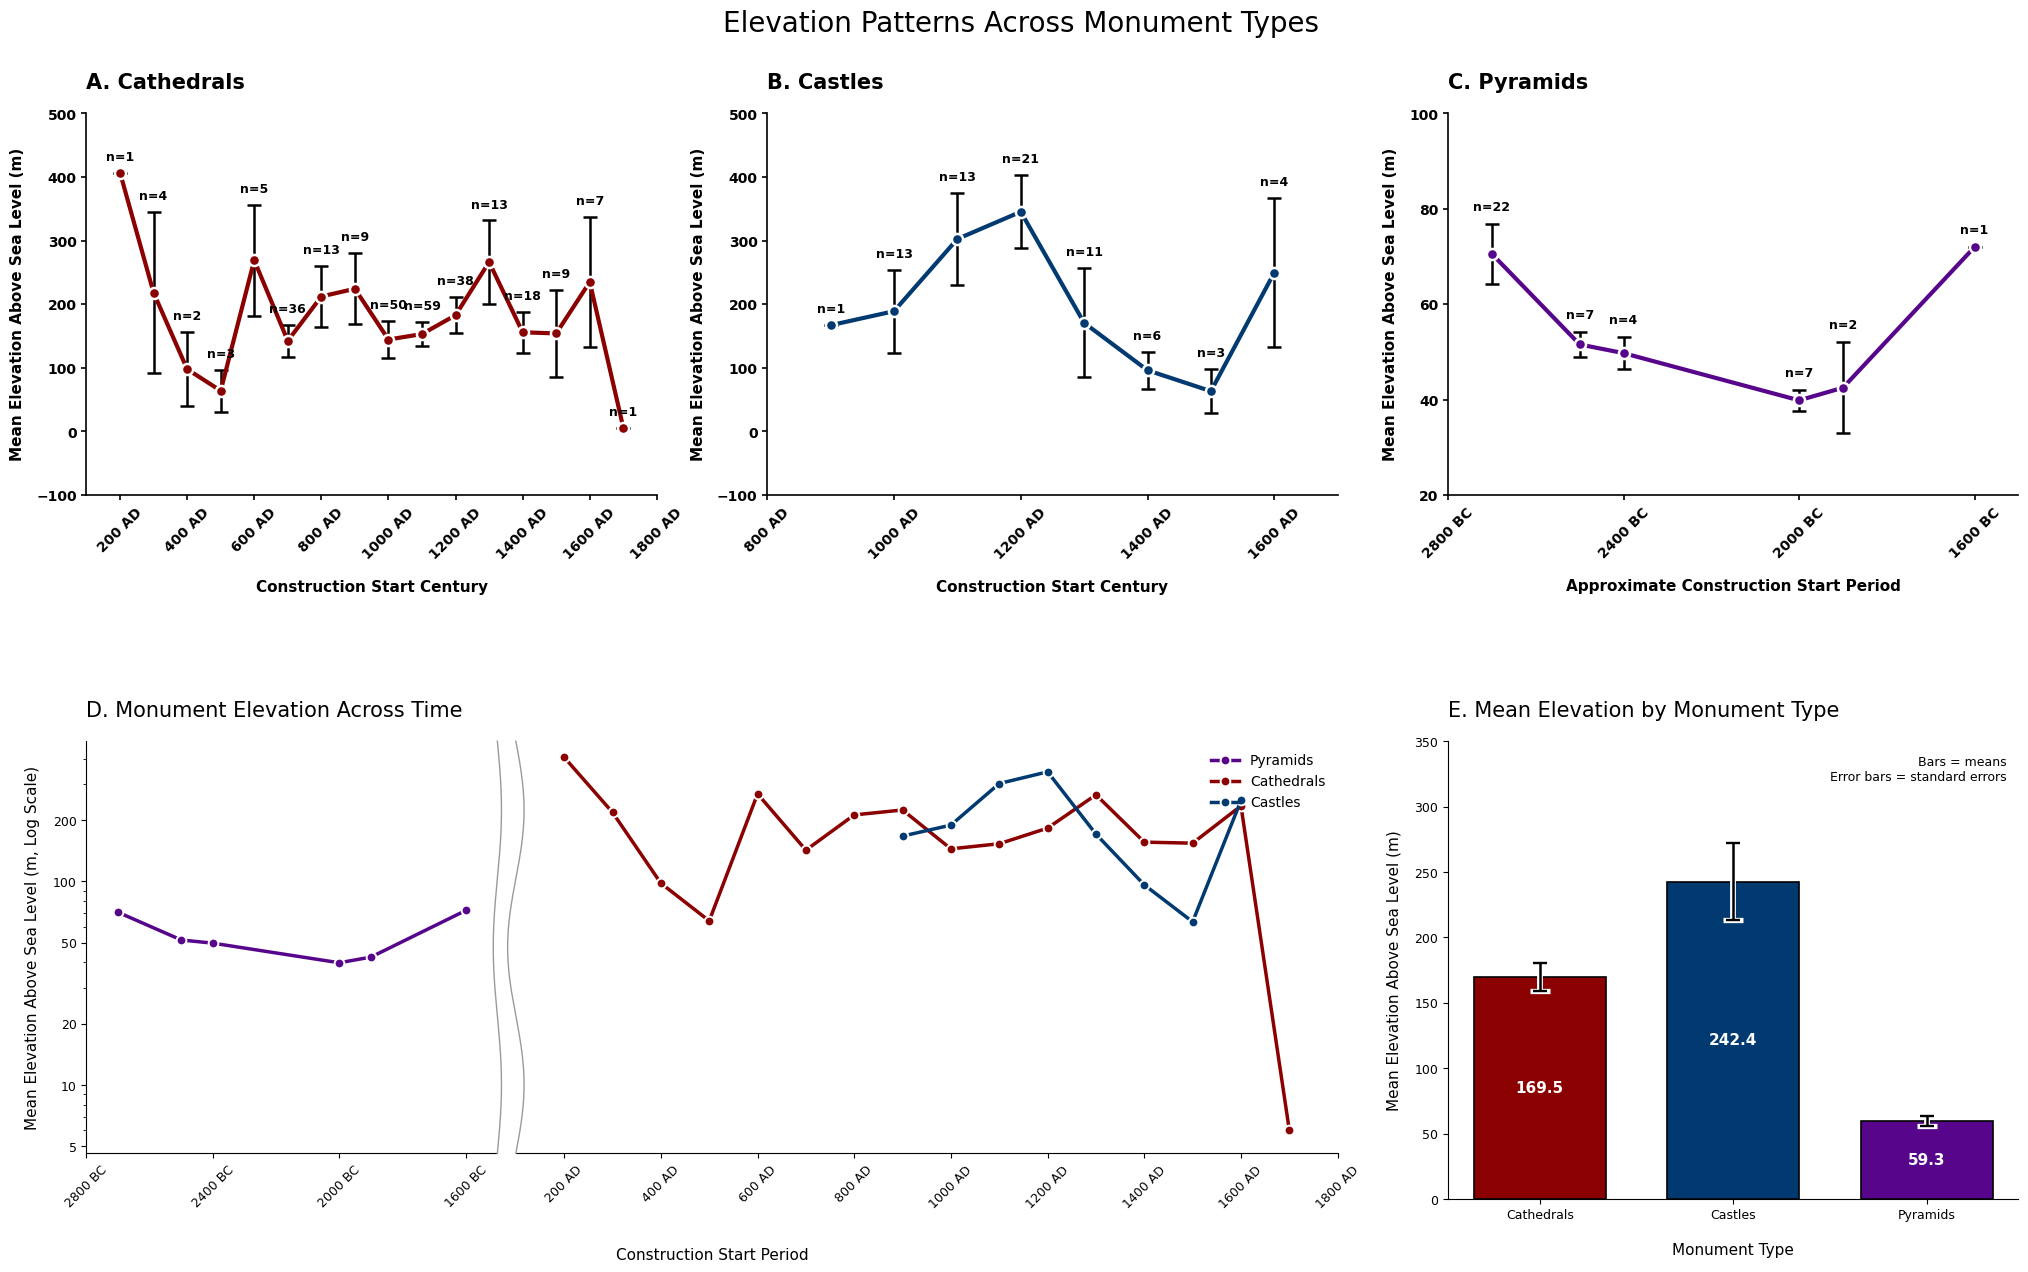


TEMPORAL ELEVATION SUMMARIES

Cathedrals by 100-year period:
 time_bin  mean_elevation  std_elevation  count  standard_error
      200      407.000000            NaN      1        0.000000
      300      218.250000     253.617001      4      126.808501
      400       98.000000      82.024387      2       58.000000
      500       64.000000      57.157677      3       33.000000
      600      269.200000     194.983845      5       87.199427
      700      142.472222     148.139796     36       24.689966
      800      212.153846     174.227268     13       48.321950
      900      224.333333     168.324092      9       56.108031
     1000      144.540000     203.055055     50       28.716321
     1100      153.135593     145.626525     59       18.958959
     1200      182.736842     172.434192     38       27.972520
     1300      266.384615     235.402683     13       65.288957
     1400      155.944444     135.496244     18       31.936771
     1500      154.111111     206.162220  

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


# ============================================================
# 1. SETTINGS
# ============================================================

DATA_PATH = (
    "monuments_harmonized_cathedral_castle_"
    "manual_duration_corrected.csv"
)

COLORS = {
    "cathedral": "#8B0000",
    "castle": "#003A70",
    "pyramid": "#57068C"
}

DISPLAY_LABELS = {
    "cathedral": "Cathedrals",
    "castle": "Castles",
    "pyramid": "Pyramids"
}

BAR_ORDER = [
    "cathedral",
    "castle",
    "pyramid"
]

DPI = 300
TIME_BIN_WIDTH = 100

# Wide five-panel composite
COMPOSITE_FIG_SIZE = (21, 13)

# Temporal x-axis padding
CATHEDRAL_X_PADDING = 100
CASTLE_X_PADDING = 100
PYRAMID_X_PADDING = 100
COMBINED_X_PADDING = 100

# Layout spacing
HSPACE = 0.62
WSPACE = 0.48


# ------------------------------------------------------------
# TOP PANELS A, B, AND C
# ------------------------------------------------------------

TOP_TEMPORAL_LINEWIDTH = 3.0
TOP_TEMPORAL_MARKERSIZE = 8
TOP_TEMPORAL_MARKER_EDGEWIDTH = 1.8

TOP_TEMPORAL_ERROR_LINEWIDTH = 1.8
TOP_TEMPORAL_ERROR_CAPSIZE = 5
TOP_TEMPORAL_ERROR_CAPTHICK = 1.7

TOP_PANEL_TITLE_FONTSIZE = 15
TOP_PANEL_AXIS_FONTSIZE = 11
TOP_PANEL_TICK_FONTSIZE = 10

N_LABEL_FONTSIZE = 9


# ------------------------------------------------------------
# PANEL D
# ------------------------------------------------------------

COMBINED_LINEWIDTH = 2.5
COMBINED_MARKERSIZE = 7
COMBINED_MARKER_EDGEWIDTH = 1.4

# Relative widths of the two portions of the broken x-axis.
# The pyramid period occupies one-third of Panel D and the
# cathedral/castle period occupies two-thirds.
BROKEN_AXIS_WIDTH_RATIOS = [1, 2]

# Narrow gap between the two parts of the broken x-axis
BROKEN_AXIS_WSPACE = 0.03


# ------------------------------------------------------------
# PANEL E
# ------------------------------------------------------------

BAR_WIDTH = 0.68

# White outline behind error bars
WHITE_ERROR_LINEWIDTH = 4.2
WHITE_ERROR_CAPSIZE = 7
WHITE_ERROR_CAPTHICK = 3.8

# Black error bars over white outline
BLACK_ERROR_LINEWIDTH = 1.8
BLACK_ERROR_CAPSIZE = 5
BLACK_ERROR_CAPTHICK = 1.7


# ============================================================
# 2. LOAD AND CLEAN DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

required_columns = [
    "monument_type",
    "start_year",
    "elevation_m"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        + ", ".join(missing_columns)
    )

df["monument_type"] = (
    df["monument_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["start_year"] = pd.to_numeric(
    df["start_year"],
    errors="coerce"
)

df["elevation_m"] = pd.to_numeric(
    df["elevation_m"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "monument_type",
        "start_year",
        "elevation_m"
    ]
).copy()

df = df[
    df["monument_type"].isin(COLORS.keys())
].copy()

if df.empty:
    raise ValueError(
        "No valid monument records remain after cleaning."
    )


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def clean_axes(ax):
    """Remove unnecessary gridlines and borders."""

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=9
    )


def embolden_top_panel(ax):
    """Make Panels A, B, and C visually heavier."""

    ax.title.set_fontweight("bold")

    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")

    for tick_label in ax.get_xticklabels():
        tick_label.set_fontweight("bold")
        tick_label.set_fontsize(
            TOP_PANEL_TICK_FONTSIZE
        )

    for tick_label in ax.get_yticklabels():
        tick_label.set_fontweight("bold")
        tick_label.set_fontsize(
            TOP_PANEL_TICK_FONTSIZE
        )

    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.tick_params(
        axis="both",
        which="major",
        width=1.2
    )


def floor_to_interval(value, interval):
    """Round downward to the nearest interval."""

    return int(
        interval * np.floor(value / interval)
    )


def ceil_to_interval(value, interval):
    """Round upward to the nearest interval."""

    return int(
        interval * np.ceil(value / interval)
    )


def format_historical_year(value, position=None):
    """Format negative years as BC and positive years as AD."""

    year = int(round(value))

    if year < 0:
        return f"{abs(year)} BC"

    if year > 0:
        return f"{year} AD"

    return "BC/AD"


def assign_time_bins(
    data,
    year_column="start_year",
    bin_width=100
):
    """Assign every monument to a regular temporal bin."""

    result = data.copy()

    result["time_bin"] = (
        np.floor(
            result[year_column] / bin_width
        ) * bin_width
    ).astype(int)

    return result


def make_temporal_summary(
    data,
    x_column="time_bin",
    elevation_column="elevation_m"
):
    """
    Calculate mean elevation, standard deviation, count,
    and standard error within each temporal bin.
    """

    grouped = (
        data.groupby(x_column)[elevation_column]
        .agg(
            mean_elevation="mean",
            std_elevation="std",
            count="count"
        )
        .reset_index()
        .sort_values(x_column)
    )

    grouped["standard_error"] = (
        grouped["std_elevation"]
        / np.sqrt(grouped["count"])
    )

    grouped["standard_error"] = (
        grouped["standard_error"]
        .fillna(0)
    )

    return grouped


def make_overall_summary(
    data,
    elevation_column="elevation_m"
):
    """
    Calculate overall mean elevation and standard error for each
    monument type.
    """

    summary = (
        data.groupby("monument_type")[elevation_column]
        .agg(
            count="count",
            mean_elevation="mean",
            std_elevation="std"
        )
        .reset_index()
    )

    summary["standard_error"] = (
        summary["std_elevation"]
        / np.sqrt(summary["count"])
    )

    summary["standard_error"] = (
        summary["standard_error"]
        .fillna(0)
    )

    order_map = {
        monument: index
        for index, monument in enumerate(BAR_ORDER)
    }

    summary["plot_order"] = (
        summary["monument_type"]
        .map(order_map)
    )

    return (
        summary
        .sort_values("plot_order")
        .reset_index(drop=True)
    )


def plot_temporal_with_errorbars(
    ax,
    grouped,
    monument
):
    """Plot temporal mean elevation with standard-error bars."""

    ax.errorbar(
        grouped["time_bin"],
        grouped["mean_elevation"],
        yerr=grouped["standard_error"],

        fmt="o-",

        color=COLORS[monument],
        linewidth=TOP_TEMPORAL_LINEWIDTH,

        markersize=TOP_TEMPORAL_MARKERSIZE,
        markerfacecolor=COLORS[monument],
        markeredgecolor="white",
        markeredgewidth=TOP_TEMPORAL_MARKER_EDGEWIDTH,

        ecolor="black",
        elinewidth=TOP_TEMPORAL_ERROR_LINEWIDTH,
        capsize=TOP_TEMPORAL_ERROR_CAPSIZE,
        capthick=TOP_TEMPORAL_ERROR_CAPTHICK,

        label=DISPLAY_LABELS[monument],
        zorder=3
    )


def plot_temporal_without_errorbars(
    ax,
    grouped,
    monument
):
    """Plot temporal mean elevation without error bars."""

    ax.plot(
        grouped["time_bin"],
        grouped["mean_elevation"],

        marker="o",

        color=COLORS[monument],
        linewidth=COMBINED_LINEWIDTH,

        markersize=COMBINED_MARKERSIZE,
        markerfacecolor=COLORS[monument],
        markeredgecolor="white",
        markeredgewidth=COMBINED_MARKER_EDGEWIDTH,

        label=DISPLAY_LABELS[monument],
        zorder=3
    )


def add_n_labels(
    ax,
    grouped,
    offset_fraction=0.025,
    fontsize=9
):
    """Add bold sample-size labels above standard-error bars."""

    y_minimum, y_maximum = ax.get_ylim()

    offset = (
        y_maximum - y_minimum
    ) * offset_fraction

    for _, row in grouped.iterrows():
        ax.text(
            row["time_bin"],
            row["mean_elevation"]
            + row["standard_error"]
            + offset,

            f"n={int(row['count'])}",

            ha="center",
            va="bottom",

            fontsize=fontsize,
            fontweight="bold",
            color="black",

            clip_on=False,
            zorder=5
        )


def set_temporal_x_axis(
    ax,
    grouped,
    tick_spacing,
    padding,
    rotation=45
):
    """Set a padded historical x-axis."""

    first_point = grouped["time_bin"].min()
    last_point = grouped["time_bin"].max()

    ax.set_xlim(
        first_point - padding,
        last_point + padding
    )

    tick_start = floor_to_interval(
        first_point,
        tick_spacing
    )

    tick_end = ceil_to_interval(
        last_point,
        tick_spacing
    )

    ticks = np.arange(
        tick_start,
        tick_end + tick_spacing,
        tick_spacing
    )

    ax.xaxis.set_major_locator(
        FixedLocator(ticks)
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(format_historical_year)
    )

    ax.tick_params(
        axis="x",
        rotation=rotation
    )


def set_linear_y_axis(
    ax,
    grouped_list,
    tick_spacing,
    expansion=1.10,
    include_error=True
):
    """Set a linear y-axis for one or more elevation series."""

    lower_values = []
    upper_values = []

    for grouped in grouped_list:

        means = grouped["mean_elevation"].copy()

        if include_error:
            lower = means - grouped["standard_error"]
            upper = means + grouped["standard_error"]
        else:
            lower = means
            upper = means

        lower_values.extend(
            lower.tolist()
        )

        upper_values.extend(
            upper.tolist()
        )

    lowest_value = min(
        lower_values
    )

    highest_value = max(
        upper_values
    )

    value_range = max(
        highest_value - lowest_value,
        tick_spacing
    )

    y_minimum = (
        np.floor(
            (
                lowest_value
                - value_range * 0.08
            )
            / tick_spacing
        )
        * tick_spacing
    )

    y_maximum = (
        np.ceil(
            (
                highest_value
                + value_range * (expansion - 1)
            )
            / tick_spacing
        )
        * tick_spacing
    )

    ax.set_ylim(
        y_minimum,
        y_maximum
    )

    ax.set_yticks(
        np.arange(
            y_minimum,
            y_maximum + tick_spacing,
            tick_spacing
        )
    )


def format_plain_number(value, position=None):
    """
    Format log-axis tick values as ordinary numbers instead
    of scientific notation.
    """

    if value >= 1:
        return f"{value:g}"

    return f"{value:.1f}"


def set_shared_log_y_axis(
    ax_list,
    grouped_list,
    lower_expansion=1.30,
    upper_expansion=1.20
):
    """
    Apply the same logarithmic y-axis limits and ticks to
    multiple axes.

    Logarithmic axes require strictly positive mean elevations.
    """

    positive_values = []

    for grouped in grouped_list:

        values = grouped[
            "mean_elevation"
        ].to_numpy()

        positive_values.extend(
            values[values > 0].tolist()
        )

        if np.any(values <= 0):
            raise ValueError(
                "Panel D cannot use a logarithmic y-axis because "
                "one or more temporal mean elevations are zero "
                "or negative."
            )

    if not positive_values:
        raise ValueError(
            "Panel D cannot use a logarithmic y-axis because "
            "no positive mean-elevation values were found."
        )

    lowest_value = min(positive_values)
    highest_value = max(positive_values)

    y_minimum = (
        lowest_value / lower_expansion
    )

    y_maximum = (
        highest_value * upper_expansion
    )

    tick_candidates = np.array([
        1,
        2,
        5,
        10,
        20,
        50,
        100,
        200,
        500,
        1000,
        2000,
        5000
    ], dtype=float)

    tick_values = tick_candidates[
        (tick_candidates >= y_minimum)
        & (tick_candidates <= y_maximum)
    ]

    for ax in ax_list:

        ax.set_yscale("log")

        ax.set_ylim(
            y_minimum,
            y_maximum
        )

        ax.yaxis.set_major_locator(
            FixedLocator(tick_values)
        )

        ax.yaxis.set_major_formatter(
            FuncFormatter(format_plain_number)
        )


def add_full_height_break_marks(
    left_ax,
    right_ax,
    wave_width=0.010,
    wave_count=1.5,
    color="#9A9A9A",
    linewidth=1.0
):
    """
    Draw a narrow, gently swaying full-height broken-axis marker.
    """

    y_values = np.linspace(
        0,
        1,
        400
    )

    wave = (
        wave_width
        * np.sin(
            wave_count
            * 2
            * np.pi
            * y_values
        )
    )

    left_ax.plot(
        1 + wave,
        y_values,

        transform=left_ax.transAxes,

        color=color,
        linewidth=linewidth,

        clip_on=False,
        zorder=10
    )

    right_ax.plot(
        wave,
        y_values,

        transform=right_ax.transAxes,

        color=color,
        linewidth=linewidth,

        clip_on=False,
        zorder=10
    )


# ============================================================
# 4. PREPARE SUMMARIES
# ============================================================

df = assign_time_bins(
    df,
    year_column="start_year",
    bin_width=TIME_BIN_WIDTH
)

temporal_summaries = {}

for monument in COLORS:

    monument_data = df[
        df["monument_type"] == monument
    ].copy()

    if monument_data.empty:
        print(
            f"Warning: no valid records found for {monument}."
        )
        continue

    temporal_summaries[monument] = (
        make_temporal_summary(
            monument_data
        )
    )

required_monuments = [
    "cathedral",
    "castle",
    "pyramid"
]

missing_monuments = [
    monument
    for monument in required_monuments
    if monument not in temporal_summaries
]

if missing_monuments:
    raise ValueError(
        "Missing monument data for: "
        + ", ".join(missing_monuments)
    )

cathedral_grouped = (
    temporal_summaries["cathedral"]
)

castle_grouped = (
    temporal_summaries["castle"]
)

pyramid_grouped = (
    temporal_summaries["pyramid"]
)

overall_summary = (
    make_overall_summary(df)
)


# ============================================================
# 5. CREATE COMPOSITE LAYOUT
#
# Top row:
# A cathedral | B castle | C pyramid
#
# Bottom row:
# D combined cathedral/castle | E overall means
# ============================================================

fig = plt.figure(
    figsize=COMPOSITE_FIG_SIZE
)

gs = GridSpec(
    nrows=2,
    ncols=6,
    figure=fig,

    height_ratios=[
        1.0,
        1.08
    ],

    hspace=HSPACE,
    wspace=WSPACE
)

ax_cathedral = fig.add_subplot(
    gs[0, 0:2]
)

ax_castle = fig.add_subplot(
    gs[0, 2:4]
)

ax_pyramid = fig.add_subplot(
    gs[0, 4:6]
)

# Bottom-left Panel D occupies four of the six columns,
# making it two-thirds of the bottom row.
#
# Panel D contains two adjacent axes to create the broken
# historical x-axis.
combined_subgrid = GridSpecFromSubplotSpec(
    nrows=1,
    ncols=2,

    subplot_spec=gs[1, 0:4],

    width_ratios=BROKEN_AXIS_WIDTH_RATIOS,
    wspace=BROKEN_AXIS_WSPACE
)

ax_combined_left = fig.add_subplot(
    combined_subgrid[0, 0]
)

ax_combined_right = fig.add_subplot(
    combined_subgrid[0, 1],
    sharey=ax_combined_left
)

# Bottom-right Panel E occupies one-third of the bottom row.
ax_bars = fig.add_subplot(
    gs[1, 4:6]
)


# ============================================================
# 6. PANEL A: CATHEDRALS
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    monument="cathedral"
)

set_temporal_x_axis(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    tick_spacing=200,
    padding=CATHEDRAL_X_PADDING
)

set_linear_y_axis(
    ax=ax_cathedral,
    grouped_list=[
        cathedral_grouped
    ],
    tick_spacing=100,
    expansion=1.15,
    include_error=True
)

add_n_labels(
    ax=ax_cathedral,
    grouped=cathedral_grouped,
    offset_fraction=0.025,
    fontsize=N_LABEL_FONTSIZE
)

ax_cathedral.set_title(
    "A. Cathedrals",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_cathedral.set_xlabel(
    "Construction Start Century",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_cathedral.set_ylabel(
    "Mean Elevation Above Sea Level (m)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_cathedral
)

embolden_top_panel(
    ax_cathedral
)


# ============================================================
# 7. PANEL B: CASTLES
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_castle,
    grouped=castle_grouped,
    monument="castle"
)

set_temporal_x_axis(
    ax=ax_castle,
    grouped=castle_grouped,
    tick_spacing=200,
    padding=CASTLE_X_PADDING
)

set_linear_y_axis(
    ax=ax_castle,
    grouped_list=[
        castle_grouped
    ],
    tick_spacing=100,
    expansion=1.15,
    include_error=True
)

add_n_labels(
    ax=ax_castle,
    grouped=castle_grouped,
    offset_fraction=0.025,
    fontsize=N_LABEL_FONTSIZE
)

ax_castle.set_title(
    "B. Castles",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_castle.set_xlabel(
    "Construction Start Century",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_castle.set_ylabel(
    "Mean Elevation Above Sea Level (m)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_castle
)

embolden_top_panel(
    ax_castle
)


# ============================================================
# 8. PANEL C: PYRAMIDS
# ============================================================

plot_temporal_with_errorbars(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    monument="pyramid"
)

set_temporal_x_axis(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    tick_spacing=400,
    padding=PYRAMID_X_PADDING
)

set_linear_y_axis(
    ax=ax_pyramid,
    grouped_list=[
        pyramid_grouped
    ],
    tick_spacing=20,
    expansion=1.18,
    include_error=True
)

add_n_labels(
    ax=ax_pyramid,
    grouped=pyramid_grouped,
    offset_fraction=0.028,
    fontsize=N_LABEL_FONTSIZE
)

ax_pyramid.set_title(
    "C. Pyramids",
    fontsize=TOP_PANEL_TITLE_FONTSIZE,
    fontweight="bold",
    pad=18,
    loc="left"
)

ax_pyramid.set_xlabel(
    "Approximate Construction Start Period",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=13
)

ax_pyramid.set_ylabel(
    "Mean Elevation Above Sea Level (m)",
    fontsize=TOP_PANEL_AXIS_FONTSIZE,
    fontweight="bold",
    labelpad=8
)

clean_axes(
    ax_pyramid
)

embolden_top_panel(
    ax_pyramid
)


# ============================================================
# 9. PANEL D: ALL THREE MONUMENT TYPES
#
# LEFT SECTION:
# Pyramids during the BC period
#
# RIGHT SECTION:
# Cathedrals and castles during the AD period
#
# BROKEN X-AXIS
# LOGARITHMIC Y-AXIS
# NO ERROR BARS
# ============================================================


# ------------------------------------------------------------
# Left segment: pyramids
# ------------------------------------------------------------

plot_temporal_without_errorbars(
    ax=ax_combined_left,
    grouped=pyramid_grouped,
    monument="pyramid"
)


# ------------------------------------------------------------
# Right segment: cathedrals and castles
# ------------------------------------------------------------

plot_temporal_without_errorbars(
    ax=ax_combined_right,
    grouped=cathedral_grouped,
    monument="cathedral"
)

plot_temporal_without_errorbars(
    ax=ax_combined_right,
    grouped=castle_grouped,
    monument="castle"
)


# ------------------------------------------------------------
# Left historical x-axis for pyramids
# ------------------------------------------------------------

set_temporal_x_axis(
    ax=ax_combined_left,
    grouped=pyramid_grouped,
    tick_spacing=400,
    padding=PYRAMID_X_PADDING
)


# ------------------------------------------------------------
# Right historical x-axis for cathedrals and castles
# ------------------------------------------------------------

combined_first_point = min(
    cathedral_grouped["time_bin"].min(),
    castle_grouped["time_bin"].min()
)

combined_last_point = max(
    cathedral_grouped["time_bin"].max(),
    castle_grouped["time_bin"].max()
)

ax_combined_right.set_xlim(
    combined_first_point - COMBINED_X_PADDING,
    combined_last_point + COMBINED_X_PADDING
)

combined_tick_start = floor_to_interval(
    combined_first_point,
    200
)

combined_tick_end = ceil_to_interval(
    combined_last_point,
    200
)

combined_ticks = np.arange(
    combined_tick_start,
    combined_tick_end + 200,
    200
)

ax_combined_right.xaxis.set_major_locator(
    FixedLocator(combined_ticks)
)

ax_combined_right.xaxis.set_major_formatter(
    FuncFormatter(format_historical_year)
)

ax_combined_right.tick_params(
    axis="x",
    rotation=45
)


# ------------------------------------------------------------
# Shared logarithmic y-axis
# ------------------------------------------------------------

set_shared_log_y_axis(
    ax_list=[
        ax_combined_left,
        ax_combined_right
    ],
    grouped_list=[
        pyramid_grouped,
        cathedral_grouped,
        castle_grouped
    ]
)


# ------------------------------------------------------------
# Panel title and y-axis title
# ------------------------------------------------------------

ax_combined_left.set_title(
    "D. Monument Elevation Across Time",
    fontsize=15,
    pad=18,
    loc="left"
)

ax_combined_left.set_ylabel(
    "Mean Elevation Above Sea Level (m, Log Scale)",
    fontsize=11,
    labelpad=9
)


# ------------------------------------------------------------
# Legend collected from both halves
# ------------------------------------------------------------

left_handles, left_labels = (
    ax_combined_left.get_legend_handles_labels()
)

right_handles, right_labels = (
    ax_combined_right.get_legend_handles_labels()
)

combined_handles = (
    left_handles
    + right_handles
)

combined_labels = (
    left_labels
    + right_labels
)

ax_combined_right.legend(
    combined_handles,
    combined_labels,

    frameon=False,
    fontsize=10,
    loc="upper right"
)


# ------------------------------------------------------------
# Basic axis cleanup
# ------------------------------------------------------------

clean_axes(
    ax_combined_left
)

clean_axes(
    ax_combined_right
)


# ------------------------------------------------------------
# Remove the touching inner spines
# ------------------------------------------------------------

ax_combined_left.spines[
    "right"
].set_visible(False)

ax_combined_right.spines[
    "left"
].set_visible(False)


# ------------------------------------------------------------
# Only show y-axis labels on the left portion
# ------------------------------------------------------------

ax_combined_right.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False
)


# ------------------------------------------------------------
# Add full-height swaying broken-axis indicators
# ------------------------------------------------------------

add_full_height_break_marks(
    left_ax=ax_combined_left,
    right_ax=ax_combined_right,

    wave_width=0.010,
    wave_count=1.5,
    color="#9A9A9A",
    linewidth=1.0
)


# ============================================================
# 10. PANEL E: OVERALL MEAN ELEVATION BAR CHART
# ============================================================

x_positions = np.arange(
    len(overall_summary)
)

bar_colors = [
    COLORS[monument]
    for monument in overall_summary["monument_type"]
]

bars = ax_bars.bar(
    x_positions,
    overall_summary["mean_elevation"],

    width=BAR_WIDTH,

    color=bar_colors,
    edgecolor="black",
    linewidth=1.2,

    zorder=2
)


# ------------------------------------------------------------
# White outline beneath error bars
# ------------------------------------------------------------

ax_bars.errorbar(
    x_positions,
    overall_summary["mean_elevation"],
    yerr=overall_summary["standard_error"],

    fmt="none",

    ecolor="white",
    elinewidth=WHITE_ERROR_LINEWIDTH,
    capsize=WHITE_ERROR_CAPSIZE,
    capthick=WHITE_ERROR_CAPTHICK,

    zorder=3
)


# ------------------------------------------------------------
# Black error bars
# ------------------------------------------------------------

ax_bars.errorbar(
    x_positions,
    overall_summary["mean_elevation"],
    yerr=overall_summary["standard_error"],

    fmt="none",

    ecolor="black",
    elinewidth=BLACK_ERROR_LINEWIDTH,
    capsize=BLACK_ERROR_CAPSIZE,
    capthick=BLACK_ERROR_CAPTHICK,

    zorder=4
)


# ------------------------------------------------------------
# Mean labels inside bars
# ------------------------------------------------------------

for position, row in zip(
    x_positions,
    overall_summary.itertuples(index=False)
):
    ax_bars.text(
        position,
        row.mean_elevation * 0.50,

        f"{row.mean_elevation:.1f}",

        ha="center",
        va="center",

        fontsize=11,
        fontweight="bold",
        color="white",

        zorder=5
    )


ax_bars.set_xticks(
    x_positions
)

ax_bars.set_xticklabels([
    DISPLAY_LABELS[monument]
    for monument in overall_summary["monument_type"]
])


# ------------------------------------------------------------
# Panel E y-axis
# Start at zero because elevation means are positive
# ------------------------------------------------------------

maximum_bar_extent = (
    overall_summary["mean_elevation"]
    + overall_summary["standard_error"]
).max()

bar_y_maximum = (
    np.ceil(
        maximum_bar_extent
        * 1.15
        / 50
    ) * 50
)

ax_bars.set_ylim(
    0,
    bar_y_maximum
)

ax_bars.set_yticks(
    np.arange(
        0,
        bar_y_maximum + 50,
        50
    )
)


ax_bars.set_title(
    "E. Mean Elevation by Monument Type",
    fontsize=15,
    pad=18,
    loc="left"
)

ax_bars.set_xlabel(
    "Monument Type",
    fontsize=11,
    labelpad=15
)

ax_bars.set_ylabel(
    "Mean Elevation Above Sea Level (m)",
    fontsize=11,
    labelpad=9
)

ax_bars.text(
    0.98,
    0.97,

    "Bars = means\nError bars = standard errors",

    transform=ax_bars.transAxes,

    ha="right",
    va="top",

    fontsize=9
)

clean_axes(
    ax_bars
)

# ============================================================
# 11. FINAL LAYOUT
# ============================================================

fig.suptitle(
    "Elevation Patterns Across Monument Types",
    fontsize=20,
    y=0.975
)

fig.subplots_adjust(
    left=0.055,
    right=0.975,
    bottom=0.095,
    top=0.895,
    hspace=HSPACE,
    wspace=WSPACE
)


# ------------------------------------------------------------
# Center a single x-axis title beneath both portions of Panel D
# ------------------------------------------------------------

combined_left_position = (
    ax_combined_left.get_position()
)

combined_right_position = (
    ax_combined_right.get_position()
)

combined_center_x = (
    combined_left_position.x0
    + combined_right_position.x1
) / 2

combined_xlabel_y = (
    min(
        combined_left_position.y0,
        combined_right_position.y0
    )
    - 0.072
)

fig.text(
    combined_center_x,
    combined_xlabel_y,

    "Construction Start Period",

    ha="center",
    va="top",

    fontsize=11
)


# ------------------------------------------------------------
# Extend Panel E downward
#
# Panel D has rotated historical labels and therefore extends
# farther visually below its plotting area. Panel E is expanded
# downward to produce a closer overall visual match.
# ------------------------------------------------------------

panel_e_position = (
    ax_bars.get_position()
)

panel_e_downward_extension = 0.035

ax_bars.set_position([
    panel_e_position.x0,
    panel_e_position.y0 - panel_e_downward_extension,
    panel_e_position.width,
    panel_e_position.height + panel_e_downward_extension
])


# ============================================================
# 12. SAVE AND DISPLAY
# ============================================================

composite_figure_path = (
    "elevation_five_panel_broken_axis_log_scale.png"
)

fig.savefig(
    composite_figure_path,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ============================================================
# 13. PRINT SUMMARIES
# ============================================================

print("\n" + "=" * 70)
print("TEMPORAL ELEVATION SUMMARIES")
print("=" * 70)

for monument in [
    "cathedral",
    "castle",
    "pyramid"
]:

    print(
        f"\n{DISPLAY_LABELS[monument]} "
        f"by {TIME_BIN_WIDTH}-year period:"
    )

    print(
        temporal_summaries[
            monument
        ].to_string(index=False)
    )


print("\n" + "=" * 70)
print("OVERALL ELEVATION SUMMARY")
print("=" * 70)

print(
    overall_summary[
        [
            "monument_type",
            "count",
            "mean_elevation",
            "std_elevation",
            "standard_error"
        ]
    ].to_string(index=False)
)

print("\nSaved figure:")
print(composite_figure_path)

In [9]:
# ============================================================
# Monument Separability Tests
# Cathedrals vs Castles vs Pyramids
#
# Features:
#   - elevation_m
#   - duration_years_harmonized
#   - log_area_m2
#
# Target:
#   - monument_type
#
# Includes:
#   1. Full complete-case tests
#   2. Majority-class baseline
#   3. Logistic regression, unweighted
#   4. Logistic regression, class weighted
#   5. Linear SVM, unweighted
#   6. Linear SVM, class weighted
#   7. One-off undersampling checks
#   8. 30 repeated undersampling robustness checks
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
from sklearn.utils import resample


# ------------------------------------------------------------
# 1. Load clean harmonized complete-case file
# ------------------------------------------------------------

FILE_PATH = "monuments_harmonized_cathedral_castle_manual_duration_corrected.csv"

df = pd.read_csv(FILE_PATH)

FEATURES = [
    "elevation_m",
    "duration_years_harmonized",
    "log_area_m2"
]

TARGET = "monument_type"

# Keep only rows with required modeling features
model_df = df.dropna(subset=FEATURES + [TARGET]).copy()

# Ensure numeric features
for col in FEATURES:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna(subset=FEATURES + [TARGET]).copy()

X = model_df[FEATURES]
y = model_df[TARGET]

print("\n" + "#" * 80)
print("Dataset summary")
print("#" * 80)

print("\nClass counts:")
print(y.value_counts())

print("\nClass proportions:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTotal complete-case rows:", len(model_df))


# ------------------------------------------------------------
# 2. Model definitions
# ------------------------------------------------------------

def model_list():
    """
    Returns all models used in the separability analysis.
    """

    return [
        (
            "Majority-class baseline",
            DummyClassifier(strategy="most_frequent")
        ),

        (
            "Logistic regression, unweighted",
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    multi_class="multinomial",
                    solver="lbfgs",
                    max_iter=5000,
                    random_state=42
                ))
            ])
        ),

        (
            "Logistic regression, class weighted",
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    multi_class="multinomial",
                    solver="lbfgs",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=42
                ))
            ])
        ),

        (
            "Linear SVM, unweighted",
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearSVC(
                    max_iter=20000,
                    random_state=42
                ))
            ])
        ),

        (
            "Linear SVM, class weighted",
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearSVC(
                    class_weight="balanced",
                    max_iter=20000,
                    random_state=42
                ))
            ])
        )
    ]


# ------------------------------------------------------------
# 3. Evaluation helpers
# ------------------------------------------------------------

def get_cv_scores_only(name, model, X, y, cv):
    """
    Returns mean cross-validated accuracy, balanced accuracy,
    and macro F1 without printing confusion matrices.
    Used for repeated robustness checks.
    """

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro"
    }

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "macro_f1": scores["test_macro_f1"].mean()
    }


def evaluate_model_verbose(name, model, X, y, cv):
    """
    Runs stratified cross-validation and prints:
      - accuracy
      - balanced accuracy
      - macro F1
      - confusion matrix
      - classification report

    Returns a one-row result dictionary.
    """

    result = get_cv_scores_only(name, model, X, y, cv)

    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=cv
    )

    labels = sorted(y.unique())

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print(f"Accuracy:          {result['accuracy']:.4f}")
    print(f"Balanced accuracy: {result['balanced_accuracy']:.4f}")
    print(f"Macro F1:          {result['macro_f1']:.4f}")

    print("\nConfusion matrix:")
    cm = confusion_matrix(y, y_pred, labels=labels)

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{label}" for label in labels],
        columns=[f"pred_{label}" for label in labels]
    )

    print(cm_df)

    print("\nClassification report:")
    print(classification_report(y, y_pred, labels=labels))

    return result


def run_model_suite_verbose(X, y, title):
    """
    Runs all models on a given dataset and prints full output.
    """

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    print("\n\n" + "#" * 80)
    print(title)
    print("#" * 80)

    print("\nClass counts for this test:")
    print(y.value_counts())

    results = []

    for name, model in model_list():
        result = evaluate_model_verbose(
            name=name,
            model=model,
            X=X,
            y=y,
            cv=cv
        )
        results.append(result)

    results_df = pd.DataFrame(results)

    print("\nSummary table:")
    print(results_df)

    return results_df


# ------------------------------------------------------------
# 4. Full complete-case separability tests
# ------------------------------------------------------------

full_results = run_model_suite_verbose(
    X=X,
    y=y,
    title="Full complete-case separability tests"
)

full_results["test_set"] = "full_complete_case"


# ------------------------------------------------------------
# 5. Undersampling helper functions
# ------------------------------------------------------------

def downsample_all_classes_to_minimum(data, target_col, random_state=42):
    """
    Downsamples every class to the size of the smallest class.
    Example:
      cathedrals = 43
      castles = 43
      pyramids = 43
    """

    counts = data[target_col].value_counts()
    min_n = counts.min()

    sampled_parts = []

    for label in counts.index:
        subset = data[data[target_col] == label]

        sampled = resample(
            subset,
            replace=False,
            n_samples=min_n,
            random_state=random_state
        )

        sampled_parts.append(sampled)

    balanced_df = pd.concat(sampled_parts, axis=0)
    balanced_df = balanced_df.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return balanced_df


def downsample_cathedrals_to_castles_keep_pyramids(data, target_col, random_state=42):
    """
    Downsamples cathedrals to the castle count,
    keeps all castles, and keeps all pyramids.
    Example:
      cathedrals = 72
      castles = 72
      pyramids = 43
    """

    cathedral_df = data[data[target_col] == "cathedral"]
    castle_df = data[data[target_col] == "castle"]
    pyramid_df = data[data[target_col] == "pyramid"]

    castle_n = len(castle_df)

    cathedral_downsampled = resample(
        cathedral_df,
        replace=False,
        n_samples=castle_n,
        random_state=random_state
    )

    reduced_df = pd.concat(
        [cathedral_downsampled, castle_df, pyramid_df],
        axis=0
    )

    reduced_df = reduced_df.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return reduced_df


# ------------------------------------------------------------
# 6. One-off undersampling check 1:
#    All classes downsampled to smallest class
# ------------------------------------------------------------

balanced_min_df = downsample_all_classes_to_minimum(
    data=model_df,
    target_col=TARGET,
    random_state=42
)

X_balanced_min = balanced_min_df[FEATURES]
y_balanced_min = balanced_min_df[TARGET]

balanced_min_results = run_model_suite_verbose(
    X=X_balanced_min,
    y=y_balanced_min,
    title="One-off undersampling check: all classes downsampled to smallest class"
)

balanced_min_results["test_set"] = "oneoff_all_classes_to_minimum"


# ------------------------------------------------------------
# 7. One-off undersampling check 2:
#    Cathedrals downsampled to castle count, pyramids retained
# ------------------------------------------------------------

reduced_df = downsample_cathedrals_to_castles_keep_pyramids(
    data=model_df,
    target_col=TARGET,
    random_state=42
)

X_reduced = reduced_df[FEATURES]
y_reduced = reduced_df[TARGET]

reduced_results = run_model_suite_verbose(
    X=X_reduced,
    y=y_reduced,
    title="One-off undersampling check: cathedrals downsampled to castles, pyramids retained"
)

reduced_results["test_set"] = "oneoff_cathedrals_to_castles_keep_pyramids"


# ------------------------------------------------------------
# 8. Repeated undersampling robustness checks
#    30 random draws for each undersampling strategy
# ------------------------------------------------------------

N_REPEATS = 30

def repeated_undersampling_checks(model_df, features, target, n_repeats=30):
    """
    Runs 30 repeated undersampling checks for:
      1. all classes downsampled to smallest class
      2. cathedrals downsampled to castles, pyramids retained

    Returns raw per-repeat model results.
    """

    repeated_results = []

    for seed in range(n_repeats):

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed
        )

        # ----------------------------------------------------
        # Strategy 1: all classes downsampled to smallest class
        # ----------------------------------------------------

        balanced_min_df = downsample_all_classes_to_minimum(
            data=model_df,
            target_col=target,
            random_state=seed
        )

        X_balanced_min = balanced_min_df[features]
        y_balanced_min = balanced_min_df[target]

        for name, model in model_list():
            result = get_cv_scores_only(
                name=name,
                model=model,
                X=X_balanced_min,
                y=y_balanced_min,
                cv=cv
            )

            result["test_set"] = "all_classes_to_minimum"
            result["repeat"] = seed
            repeated_results.append(result)

        # ----------------------------------------------------
        # Strategy 2: cathedrals downsampled to castle count,
        #             pyramids retained
        # ----------------------------------------------------

        reduced_df = downsample_cathedrals_to_castles_keep_pyramids(
            data=model_df,
            target_col=target,
            random_state=seed
        )

        X_reduced = reduced_df[features]
        y_reduced = reduced_df[target]

        for name, model in model_list():
            result = get_cv_scores_only(
                name=name,
                model=model,
                X=X_reduced,
                y=y_reduced,
                cv=cv
            )

            result["test_set"] = "cathedrals_to_castles_keep_pyramids"
            result["repeat"] = seed
            repeated_results.append(result)

    repeated_results_df = pd.DataFrame(repeated_results)

    return repeated_results_df


repeated_results = repeated_undersampling_checks(
    model_df=model_df,
    features=FEATURES,
    target=TARGET,
    n_repeats=N_REPEATS
)

print("\n\n" + "#" * 80)
print("Repeated undersampling robustness checks: 30 random draws")
print("#" * 80)

repeated_summary = (
    repeated_results
    .groupby(["test_set", "model"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std")
    )
    .reset_index()
)

print("\nRepeated undersampling summary:")
print(repeated_summary)


# ------------------------------------------------------------
# 9. Final combined summary
# ------------------------------------------------------------

oneoff_results = pd.concat(
    [
        full_results,
        balanced_min_results,
        reduced_results
    ],
    axis=0
).reset_index(drop=True)

print("\n\n" + "#" * 80)
print("Final one-off model summary")
print("#" * 80)

print(
    oneoff_results[
        ["test_set", "model", "accuracy", "balanced_accuracy", "macro_f1"]
    ]
)


print("\n\n" + "#" * 80)
print("Final repeated undersampling summary")
print("#" * 80)

print(repeated_summary)


# ------------------------------------------------------------
# 10. Save outputs
# ------------------------------------------------------------

oneoff_results.to_csv(
    "separability_oneoff_results_summary.csv",
    index=False
)

repeated_results.to_csv(
    "separability_repeated_undersampling_30_runs_raw.csv",
    index=False
)

repeated_summary.to_csv(
    "separability_repeated_undersampling_30_runs_summary.csv",
    index=False
)

print("\nSaved files:")
print("  separability_oneoff_results_summary.csv")
print("  separability_repeated_undersampling_30_runs_raw.csv")
print("  separability_repeated_undersampling_30_runs_summary.csv")


################################################################################
Dataset summary
################################################################################

Class counts:
monument_type
cathedral    268
castle        72
pyramid       43
Name: count, dtype: int64

Class proportions:
monument_type
cathedral    69.97
castle       18.80
pyramid      11.23
Name: proportion, dtype: float64

Total complete-case rows: 383


################################################################################
Full complete-case separability tests
################################################################################

Class counts for this test:
monument_type
cathedral    268
castle        72
pyramid       43
Name: count, dtype: int64

Majority-class baseline
Accuracy:          0.6997
Balanced accuracy: 0.3333
Macro F1:          0.2744

Confusion matrix:
                pred_castle  pred_cathedral  pred_pyramid
true_castle               0              72             0


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha


Linear SVM, unweighted
Accuracy:          0.7154
Balanced accuracy: 0.4116
Macro F1:          0.3936

Confusion matrix:
                pred_castle  pred_cathedral  pred_pyramid
true_castle               2              69             1
true_cathedral            2             262             4
true_pyramid              0              33            10

Classification report:
              precision    recall  f1-score   support

      castle       0.50      0.03      0.05        72
   cathedral       0.72      0.98      0.83       268
     pyramid       0.67      0.23      0.34        43

    accuracy                           0.72       383
   macro avg       0.63      0.41      0.41       383
weighted avg       0.67      0.72      0.63       383


Linear SVM, class weighted
Accuracy:          0.6867
Balanced accuracy: 0.6437
Macro F1:          0.5485

Confusion matrix:
                pred_castle  pred_cathedral  pred_pyramid
true_castle              11              49            12
t

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho


Logistic regression, unweighted
Accuracy:          0.5990
Balanced accuracy: 0.6460
Macro F1:          0.6081

Confusion matrix:
                pred_castle  pred_cathedral  pred_pyramid
true_castle              33              23            16
true_cathedral           26              39             7
true_pyramid              3               0            40

Classification report:
              precision    recall  f1-score   support

      castle       0.53      0.46      0.49        72
   cathedral       0.63      0.54      0.58        72
     pyramid       0.63      0.93      0.75        43

    accuracy                           0.60       187
   macro avg       0.60      0.64      0.61       187
weighted avg       0.59      0.60      0.59       187


Logistic regression, class weighted
Accuracy:          0.5990
Balanced accuracy: 0.6540
Macro F1:          0.6030

Confusion matrix:
                pred_castle  pred_cathedral  pred_pyramid
true_castle              31              

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho



################################################################################
Repeated undersampling robustness checks: 30 random draws
################################################################################

Repeated undersampling summary:
                              test_set                                model  \
0               all_classes_to_minimum           Linear SVM, class weighted   
1               all_classes_to_minimum               Linear SVM, unweighted   
2               all_classes_to_minimum  Logistic regression, class weighted   
3               all_classes_to_minimum      Logistic regression, unweighted   
4               all_classes_to_minimum              Majority-class baseline   
5  cathedrals_to_castles_keep_pyramids           Linear SVM, class weighted   
6  cathedrals_to_castles_keep_pyramids               Linear SVM, unweighted   
7  cathedrals_to_castles_keep_pyramids  Logistic regression, class weighted   
8  cathedrals_to_castles_keep_pyra


################################################################################
MONUMENT CLOUDS IN THREE-FEATURE SPACE
################################################################################

Class counts:
monument_type
cathedral    268
castle        72
pyramid       43
Name: count, dtype: int64

Total complete-case observations: 383


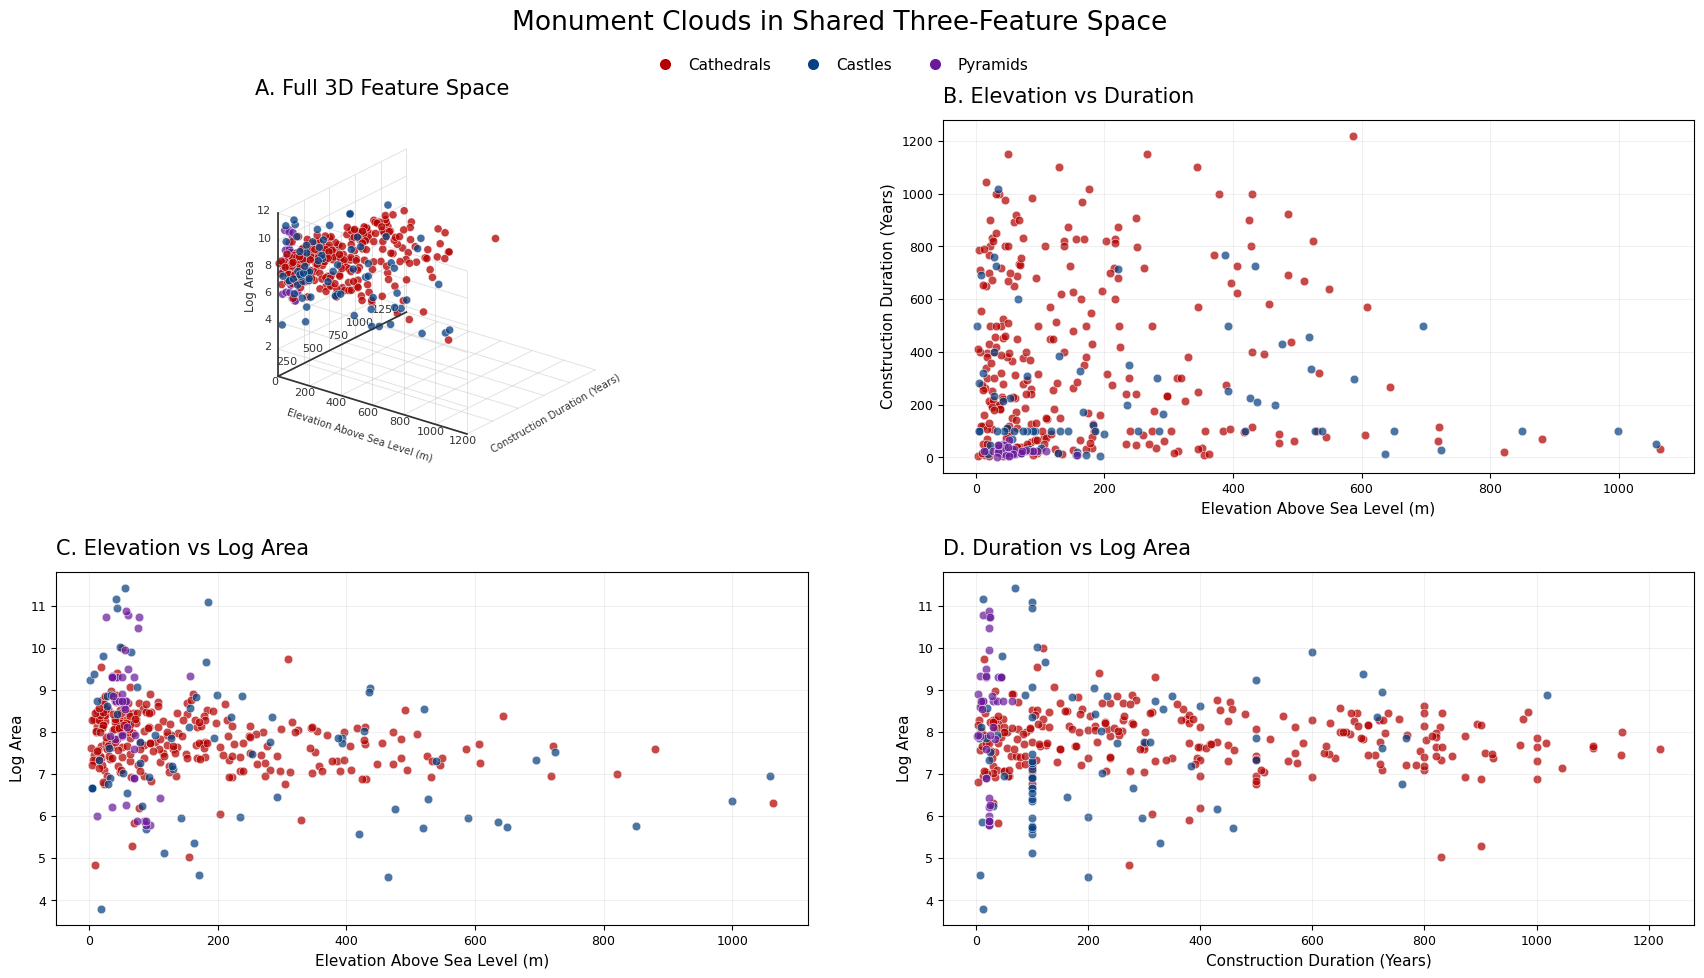


Saved figure to: monument_feature_space_clouds_wide.png


In [42]:
# ============================================================
# MONUMENT CLOUDS IN THREE-FEATURE SPACE
#
# Panels:
#   A. Full 3D feature space
#   B. Elevation vs construction duration
#   C. Elevation vs log area
#   D. Construction duration vs log area
#
# Colors indicate true monument class.
# ============================================================


# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


# ------------------------------------------------------------
# 2. Settings
# ------------------------------------------------------------

FILE_PATH = (
    "monuments_harmonized_cathedral_castle_"
    "manual_duration_corrected.csv"
)

FEATURES = [
    "elevation_m",
    "duration_years_harmonized",
    "log_area_m2"
]

TARGET = "monument_type"

CLASS_ORDER = [
    "cathedral",
    "castle",
    "pyramid"
]

DISPLAY_LABELS = {
    "cathedral": "Cathedrals",
    "castle": "Castles",
    "pyramid": "Pyramids"
}

COLORS = {
    "cathedral": "#b30000",
    "castle": "#084081",
    "pyramid": "#6a1b9a"
}

OUTPUT_PATH = "monument_feature_space_clouds_wide.png"


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(
    FILE_PATH
)


# ------------------------------------------------------------
# 4. Check required columns
# ------------------------------------------------------------

required_columns = (
    FEATURES
    + [TARGET]
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------------------
# 5. Clean target labels
# ------------------------------------------------------------

df[TARGET] = (
    df[TARGET]
    .astype(str)
    .str.strip()
    .str.lower()
)


# ------------------------------------------------------------
# 6. Convert features to numeric
# ------------------------------------------------------------

for feature in FEATURES:
    df[feature] = pd.to_numeric(
        df[feature],
        errors="coerce"
    )


# ------------------------------------------------------------
# 7. Keep required classes and complete cases
# ------------------------------------------------------------

model_df = df[
    df[TARGET].isin(
        CLASS_ORDER
    )
].copy()

model_df = model_df.dropna(
    subset=FEATURES + [TARGET]
).copy()

model_df = model_df.reset_index(
    drop=True
)

if model_df.empty:
    raise ValueError(
        "No complete-case observations remain after cleaning."
    )


# ------------------------------------------------------------
# 8. Print dataset summary
# ------------------------------------------------------------

print("\n" + "#" * 80)
print("MONUMENT CLOUDS IN THREE-FEATURE SPACE")
print("#" * 80)

print("\nClass counts:")

print(
    model_df[TARGET]
    .value_counts()
    .reindex(CLASS_ORDER)
)

print(
    "\nTotal complete-case observations:",
    len(model_df)
)


# ------------------------------------------------------------
# 9. Helper function for 2D scatter plots
# ------------------------------------------------------------

def scatter_class_2d(
    ax,
    data,
    x_column,
    y_column,
    monument_type
):
    """
    Plot one monument class on a two-dimensional axis.
    """

    subset = data[
        data[TARGET] == monument_type
    ]

    ax.scatter(
        subset[x_column],
        subset[y_column],
        s=38,
        c=COLORS[monument_type],
        alpha=0.72,
        edgecolors="white",
        linewidths=0.45,
        label=DISPLAY_LABELS[
            monument_type
        ]
    )


# ------------------------------------------------------------
# 10. Helper function for 3D scatter plot
# ------------------------------------------------------------

def scatter_class_3d(
    ax,
    data,
    monument_type
):
    """
    Plot one monument class in the three-dimensional feature
    space.
    """

    subset = data[
        data[TARGET] == monument_type
    ]

    ax.scatter(
        subset["elevation_m"],
        subset["duration_years_harmonized"],
        subset["log_area_m2"],
        s=34,
        c=COLORS[monument_type],
        alpha=0.76,
        edgecolors="white",
        linewidths=0.4,
        depthshade=True,
        label=DISPLAY_LABELS[
            monument_type
        ]
    )


# ------------------------------------------------------------
# 11. Configure a true common-origin 3D coordinate frame
# ------------------------------------------------------------

def configure_common_origin_3d_axes(
    ax,
    data
):
    """
    Replace Matplotlib's automatically positioned 3D axes with a
    custom coordinate frame in which the x, y, and z axes all
    begin at the same visible point: (0, 0, 0).

    Matplotlib normally places the three displayed 3D axis spines
    on different edges of the box depending on the camera angle.
    Merely setting each limit to begin at zero does not make the
    three visible zero labels meet. Drawing the coordinate frame
    explicitly guarantees a shared origin.
    """

    raw_x_max = data["elevation_m"].max() * 1.02
    raw_y_max = (
        data["duration_years_harmonized"].max()
        * 1.02
    )
    raw_z_max = data["log_area_m2"].max() * 1.02

    x_locator = MaxNLocator(
        nbins=6,
        integer=True
    )

    y_locator = MaxNLocator(
        nbins=6,
        integer=True
    )

    z_locator = MaxNLocator(
        nbins=6,
        integer=True
    )

    x_ticks = x_locator.tick_values(
        0,
        raw_x_max
    )

    y_ticks = y_locator.tick_values(
        0,
        raw_y_max
    )

    z_ticks = z_locator.tick_values(
        0,
        raw_z_max
    )

    x_ticks = x_ticks[
        x_ticks >= 0
    ]

    y_ticks = y_ticks[
        y_ticks >= 0
    ]

    z_ticks = z_ticks[
        z_ticks >= 0
    ]

    x_max = x_ticks[-1]
    y_max = y_ticks[-1]
    z_max = z_ticks[-1]

    ax.set_xlim(
        0,
        x_max
    )

    ax.set_ylim(
        0,
        y_max
    )

    ax.set_zlim(
        0,
        z_max
    )

    # Hide Matplotlib's automatically juggled 3D axis spines.
    # They cannot reliably be forced to share one visible corner.
    ax.set_axis_off()

    axis_color = "#333333"
    grid_color = "#C8C8C8"
    axis_linewidth = 1.25
    grid_linewidth = 0.65
    grid_alpha = 0.55

    # --------------------------------------------------------
    # Three principal axes, all beginning at (0, 0, 0)
    # --------------------------------------------------------

    ax.plot(
        [0, x_max],
        [0, 0],
        [0, 0],
        color=axis_color,
        linewidth=axis_linewidth,
        zorder=20
    )

    ax.plot(
        [0, 0],
        [0, y_max],
        [0, 0],
        color=axis_color,
        linewidth=axis_linewidth,
        zorder=20
    )

    ax.plot(
        [0, 0],
        [0, 0],
        [0, z_max],
        color=axis_color,
        linewidth=axis_linewidth,
        zorder=20
    )

    # --------------------------------------------------------
    # Light reference grids on the three origin planes
    # --------------------------------------------------------

    for x_value in x_ticks:
        ax.plot(
            [x_value, x_value],
            [0, y_max],
            [0, 0],
            color=grid_color,
            linewidth=grid_linewidth,
            alpha=grid_alpha,
            zorder=0
        )

        ax.plot(
            [x_value, x_value],
            [0, 0],
            [0, z_max],
            color=grid_color,
            linewidth=grid_linewidth,
            alpha=grid_alpha,
            zorder=0
        )

    for y_value in y_ticks:
        ax.plot(
            [0, x_max],
            [y_value, y_value],
            [0, 0],
            color=grid_color,
            linewidth=grid_linewidth,
            alpha=grid_alpha,
            zorder=0
        )

        ax.plot(
            [0, 0],
            [y_value, y_value],
            [0, z_max],
            color=grid_color,
            linewidth=grid_linewidth,
            alpha=grid_alpha,
            zorder=0
        )

    for z_value in z_ticks:
        ax.plot(
            [0, x_max],
            [0, 0],
            [z_value, z_value],
            color=grid_color,
            linewidth=grid_linewidth,
            alpha=grid_alpha,
            zorder=0
        )

        ax.plot(
            [0, 0],
            [0, y_max],
            [z_value, z_value],
            color=grid_color,
            linewidth=grid_linewidth,
            alpha=grid_alpha,
            zorder=0
        )

    # --------------------------------------------------------
    # Tick labels
    #
    # The zero label is drawn only once at the shared origin.
    # --------------------------------------------------------

    ax.text(
        0,
        0,
        0,
        "0",
        fontsize=8,
        ha="right",
        va="top",
        color=axis_color
    )

    for x_value in x_ticks[1:]:
        ax.text(
            x_value,
            -0.035 * y_max,
            0,
            f"{x_value:g}",
            fontsize=8,
            ha="center",
            va="top",
            color=axis_color
        )

    for y_value in y_ticks[1:]:
        ax.text(
            -0.035 * x_max,
            y_value,
            0,
            f"{y_value:g}",
            fontsize=8,
            ha="right",
            va="center",
            color=axis_color
        )

    for z_value in z_ticks[1:]:
        ax.text(
            -0.035 * x_max,
            0,
            z_value,
            f"{z_value:g}",
            fontsize=8,
            ha="right",
            va="center",
            color=axis_color
        )

    # --------------------------------------------------------
    # Axis labels
    #
    # Use 2D overlay text for the titles so they stay readable
    # and remain attached to the correct visible axis after the
    # custom 3D frame and camera projection are applied.
    # --------------------------------------------------------

    # --------------------------------------------------------
    # Compact axis titles aligned with the visible axes
    #
    # These use the same visual scale as the 3D tick labels and
    # are pushed outside the number regions to avoid overlap.
    # --------------------------------------------------------

    # Elevation: beneath and parallel to the front x-axis.
    ax.text2D(
        0.3,
        0.12,
        "Elevation Above Sea Level (m)",

        transform=ax.transAxes,

        fontsize=7.2,
        rotation=-18,
        rotation_mode="anchor",
        ha="center",
        va="top",
        color=axis_color,
        clip_on=False
    )

    # Duration: outside and parallel to the diagonal y-axis.
    ax.text2D(
        0.85,
        0.17,
        "Construction Duration (Years)",

        transform=ax.transAxes,

        fontsize=7.2,
        rotation=30,
        rotation_mode="anchor",
        ha="center",
        va="center",
        color=axis_color,
        clip_on=False
    )

    # Log area: farther left than the z tick labels.
    ax.text2D(
        -0.015,
        0.53,
        "Log Area",

        transform=ax.transAxes,

        fontsize=8.5,
        rotation=90,
        rotation_mode="anchor",
        ha="center",
        va="center",
        color=axis_color,
        clip_on=False
    )

    # Perspective selected so the common-origin corner remains
    # clearly visible.
    ax.view_init(
        elev=23,
        azim=-52
    )

    try:
        ax.set_proj_type(
            "ortho"
        )
    except AttributeError:
        pass

    try:
        ax.set_box_aspect(
            (
                1.15,
                1.0,
                0.85
            )
        )
    except AttributeError:
        pass


# ------------------------------------------------------------
# 12. Create wider figure
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(18, 10)
)


# ------------------------------------------------------------
# 13. Create 2 × 2 layout
# ------------------------------------------------------------

ax_3d = fig.add_subplot(
    2,
    2,
    1,
    projection="3d"
)

ax_elevation_duration = fig.add_subplot(
    2,
    2,
    2
)

ax_elevation_area = fig.add_subplot(
    2,
    2,
    3
)

ax_duration_area = fig.add_subplot(
    2,
    2,
    4
)


# ------------------------------------------------------------
# 14. Panel A: full 3D feature space
# ------------------------------------------------------------

for monument_type in CLASS_ORDER:

    scatter_class_3d(
        ax=ax_3d,
        data=model_df,
        monument_type=monument_type
    )


ax_3d.set_title(
    "A. Full 3D Feature Space",
    fontsize=15,
    pad=18,
    loc="left"
)

configure_common_origin_3d_axes(
    ax=ax_3d,
    data=model_df
)


# ------------------------------------------------------------
# 15. Panel B: elevation vs duration
# ------------------------------------------------------------

for monument_type in CLASS_ORDER:

    scatter_class_2d(
        ax=ax_elevation_duration,
        data=model_df,
        x_column="elevation_m",
        y_column="duration_years_harmonized",
        monument_type=monument_type
    )


ax_elevation_duration.set_title(
    "B. Elevation vs Duration",
    fontsize=15,
    pad=12,
    loc="left"
)

ax_elevation_duration.set_xlabel(
    "Elevation Above Sea Level (m)",
    fontsize=11
)

ax_elevation_duration.set_ylabel(
    "Construction Duration (Years)",
    fontsize=11
)

ax_elevation_duration.tick_params(
    axis="both",
    labelsize=9
)

ax_elevation_duration.grid(
    alpha=0.18
)


# ------------------------------------------------------------
# 16. Panel C: elevation vs log area
# ------------------------------------------------------------

for monument_type in CLASS_ORDER:

    scatter_class_2d(
        ax=ax_elevation_area,
        data=model_df,
        x_column="elevation_m",
        y_column="log_area_m2",
        monument_type=monument_type
    )


ax_elevation_area.set_title(
    "C. Elevation vs Log Area",
    fontsize=15,
    pad=12,
    loc="left"
)

ax_elevation_area.set_xlabel(
    "Elevation Above Sea Level (m)",
    fontsize=11
)

ax_elevation_area.set_ylabel(
    "Log Area",
    fontsize=11
)

ax_elevation_area.tick_params(
    axis="both",
    labelsize=9
)

ax_elevation_area.grid(
    alpha=0.18
)


# ------------------------------------------------------------
# 17. Panel D: duration vs log area
# ------------------------------------------------------------

for monument_type in CLASS_ORDER:

    scatter_class_2d(
        ax=ax_duration_area,
        data=model_df,
        x_column="duration_years_harmonized",
        y_column="log_area_m2",
        monument_type=monument_type
    )


ax_duration_area.set_title(
    "D. Duration vs Log Area",
    fontsize=15,
    pad=12,
    loc="left"
)

ax_duration_area.set_xlabel(
    "Construction Duration (Years)",
    fontsize=11
)

ax_duration_area.set_ylabel(
    "Log Area",
    fontsize=11
)

ax_duration_area.tick_params(
    axis="both",
    labelsize=9
)

ax_duration_area.grid(
    alpha=0.18
)


# ------------------------------------------------------------
# 18. Common legend
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=COLORS["cathedral"],
        markeredgecolor="white",
        markersize=9,
        label="Cathedrals"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=COLORS["castle"],
        markeredgecolor="white",
        markersize=9,
        label="Castles"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=COLORS["pyramid"],
        markeredgecolor="white",
        markersize=9,
        label="Pyramids"
    )
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.956
    ),
    ncol=3,
    frameon=False,
    fontsize=11,
    handletextpad=0.5,
    columnspacing=1.8
)


# ------------------------------------------------------------
# 19. Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Monument Clouds in Shared Three-Feature Space",
    fontsize=19,
    y=0.99
)


# ------------------------------------------------------------
# 20. Layout spacing
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.065,
    right=0.975,
    bottom=0.075,
    top=0.88,
    wspace=0.18,
    hspace=0.28
)


# ------------------------------------------------------------
# 21. Save and display
# ------------------------------------------------------------

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"\nSaved figure to: {OUTPUT_PATH}"
)

In [20]:
# ============================================================
# NONLINEAR MONUMENT SEPARABILITY TESTS
#
# Cathedrals vs Castles vs Pyramids
#
# Features:
#   - elevation_m
#   - duration_years_harmonized
#   - log_area_m2
#
# Target:
#   - monument_type
#
# Models:
#   1. Majority-class baseline
#   2. RBF-kernel SVM, class weighted
#   3. Random forest, class weighted
#   4. Gradient boosting
#
# Evaluation:
#   - Nested stratified cross-validation
#   - Outer CV: estimates model performance
#   - Inner CV: selects hyperparameters
#   - Accuracy
#   - Balanced accuracy
#   - Macro F1
#   - Out-of-fold confusion matrices
#   - Classification reports
#
# Runtime improvements:
#   - Smaller parameter grids
#   - Three inner folds instead of four
#   - Each outer fold is fitted only once
#   - Predictions are collected during the same outer loop
#
# Outputs:
#   - nonlinear_separability_nested_cv_summary.csv
#   - nonlinear_separability_outer_fold_scores.csv
#   - nonlinear_separability_selected_parameters.csv
#   - nonlinear_separability_confusion_matrices.csv
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import json

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# ============================================================
# 2. SETTINGS
# ============================================================

FILE_PATH = (
    "monuments_harmonized_cathedral_castle_"
    "manual_duration_corrected.csv"
)

FEATURES = [
    "elevation_m",
    "duration_years_harmonized",
    "log_area_m2"
]

TARGET = "monument_type"

CLASS_ORDER = [
    "cathedral",
    "castle",
    "pyramid"
]

RANDOM_STATE = 42

# Five outer folds retain the same evaluation structure.
OUTER_FOLDS = 5

# Three inner folds reduce tuning time while preserving
# nested cross-validation.
INNER_FOLDS = 3

PRIMARY_TUNING_METRIC = "balanced_accuracy"

SUMMARY_PATH = (
    "nonlinear_separability_nested_cv_summary.csv"
)

FOLD_RESULTS_PATH = (
    "nonlinear_separability_outer_fold_scores.csv"
)

PARAMETERS_PATH = (
    "nonlinear_separability_selected_parameters.csv"
)

CONFUSION_MATRICES_PATH = (
    "nonlinear_separability_confusion_matrices.csv"
)


# ============================================================
# 3. LOAD AND CLEAN DATA
# ============================================================

df = pd.read_csv(
    FILE_PATH
)

required_columns = (
    FEATURES
    + [TARGET]
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        + ", ".join(missing_columns)
    )


# Standardize monument-type labels
df[TARGET] = (
    df[TARGET]
    .astype(str)
    .str.strip()
    .str.lower()
)


# Convert all modeling features to numeric
for feature in FEATURES:
    df[feature] = pd.to_numeric(
        df[feature],
        errors="coerce"
    )


# Keep only the required monument classes
model_df = df[
    df[TARGET].isin(CLASS_ORDER)
].copy()


# Keep complete cases for every required variable
model_df = model_df.dropna(
    subset=FEATURES + [TARGET]
).copy()


if model_df.empty:
    raise ValueError(
        "No complete-case observations remain after cleaning."
    )


# Verify that all three classes are present
missing_classes = [
    monument_class
    for monument_class in CLASS_ORDER
    if monument_class
    not in model_df[TARGET].unique()
]

if missing_classes:
    raise ValueError(
        "The following monument classes are missing: "
        + ", ".join(missing_classes)
    )


# Reset the index so out-of-fold predictions can be stored
# safely by positional index.
model_df = (
    model_df
    .reset_index(drop=True)
)

X = model_df[
    FEATURES
].copy()

y = model_df[
    TARGET
].copy()


# ============================================================
# 4. DATASET SUMMARY
# ============================================================

print("\n" + "#" * 80)
print("NONLINEAR MONUMENT SEPARABILITY ANALYSIS")
print("#" * 80)

print("\nFeatures:")

for feature in FEATURES:
    print(
        f"  - {feature}"
    )

print(
    f"\nTarget: {TARGET}"
)

print("\nClass counts:")

print(
    y.value_counts()
    .reindex(CLASS_ORDER)
)

print("\nClass proportions:")

print(
    (
        y.value_counts(normalize=True)
        .reindex(CLASS_ORDER)
        * 100
    ).round(2)
)

print(
    "\nTotal complete-case observations:",
    len(model_df)
)

print("\nFeature summary:")

print(
    X.describe()
    .transpose()
)


# ============================================================
# 5. CROSS-VALIDATION DEFINITIONS
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

inner_cv = StratifiedKFold(
    n_splits=INNER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE + 1
)


# ============================================================
# 6. MODEL DEFINITIONS
# ============================================================

def nonlinear_model_specifications():
    """
    Return nonlinear classifiers with compact tuning grids.

    The purpose is to test whether nonlinear boundaries improve
    separability, rather than exhaustively search every possible
    hyperparameter combination.
    """

    return [
        {
            "name": "Majority-class baseline",

            "estimator": DummyClassifier(
                strategy="most_frequent"
            ),

            "parameter_grid": {}
        },

        {
            "name": "RBF SVM, class weighted",

            "estimator": Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    SVC(
                        kernel="rbf",
                        class_weight="balanced",
                        decision_function_shape="ovr",
                        cache_size=1000
                    )
                )
            ]),

            # 4 C values × 4 gamma values = 16 combinations
            "parameter_grid": {
                "model__C": [
                    1,
                    10,
                    100,
                    1000
                ],

                "model__gamma": [
                    "scale",
                    0.01,
                    0.1,
                    1
                ]
            }
        },

        {
            "name": "Random forest, class weighted",

            "estimator": RandomForestClassifier(
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,

                # GridSearchCV handles the parallelization.
                # Keeping the forest itself at one process
                # avoids nested parallel execution.
                n_jobs=1
            ),

            # 2 × 4 × 3 × 2 = 48 combinations
            "parameter_grid": {
                "n_estimators": [
                    300,
                    500
                ],

                "max_depth": [
                    None,
                    3,
                    5,
                    8
                ],

                "min_samples_leaf": [
                    1,
                    5,
                    10
                ],

                "max_features": [
                    "sqrt",
                    1.0
                ]
            }
        },

        {
            "name": "Gradient boosting",

            "estimator": GradientBoostingClassifier(
                random_state=RANDOM_STATE
            ),

            # 3 × 3 × 3 × 2 = 54 combinations
            "parameter_grid": {
                "n_estimators": [
                    50,
                    100,
                    200
                ],

                "learning_rate": [
                    0.03,
                    0.05,
                    0.1
                ],

                "max_depth": [
                    1,
                    2,
                    3
                ],

                "min_samples_leaf": [
                    5,
                    10
                ]
            }
        }
    ]


# ============================================================
# 7. HELPER: CREATE INNER GRID SEARCH
# ============================================================

def make_nested_estimator(
    estimator,
    parameter_grid
):
    """
    Create the inner hyperparameter search.

    Balanced accuracy is used for model selection because the
    monument classes are strongly imbalanced.
    """

    return GridSearchCV(
        estimator=estimator,
        param_grid=parameter_grid,
        scoring=PRIMARY_TUNING_METRIC,
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        pre_dispatch="2*n_jobs",
        return_train_score=False,
        error_score="raise"
    )


# ============================================================
# 8. HELPER: EVALUATE ONE MODEL
# ============================================================

def evaluate_model_nested(
    model_name,
    estimator,
    parameter_grid,
    X,
    y
):
    """
    Evaluate one model using nested stratified cross-validation.

    Each outer fold is fitted only once. During that single fit:
      1. Hyperparameters are selected by inner CV.
      2. The best model predicts the outer held-out fold.
      3. Metrics and predictions are retained.

    This avoids repeating the entire nested search through a
    separate cross_val_predict call.
    """

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    # Store one held-out prediction for every observation.
    y_pred = pd.Series(
        index=y.index,
        dtype=object
    )

    fold_rows = []
    parameter_rows = []


    # --------------------------------------------------------
    # Manual outer cross-validation loop
    # --------------------------------------------------------

    for fold_number, (
        train_positions,
        test_positions
    ) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):

        X_train = X.iloc[
            train_positions
        ]

        X_test = X.iloc[
            test_positions
        ]

        y_train = y.iloc[
            train_positions
        ]

        y_test = y.iloc[
            test_positions
        ]


        # Create an unfitted copy for this outer fold
        fold_estimator = clone(
            estimator
        )


        # Inner grid search on the outer training portion only
        nested_estimator = make_nested_estimator(
            estimator=fold_estimator,
            parameter_grid=parameter_grid
        )

        nested_estimator.fit(
            X_train,
            y_train
        )


        # Predict the unseen outer test fold
        fold_predictions = nested_estimator.predict(
            X_test
        )


        # Store predictions in their original row positions
        y_pred.iloc[
            test_positions
        ] = fold_predictions


        # ----------------------------------------------------
        # Outer-fold metrics
        # ----------------------------------------------------

        fold_accuracy = accuracy_score(
            y_test,
            fold_predictions
        )

        fold_balanced_accuracy = (
            balanced_accuracy_score(
                y_test,
                fold_predictions
            )
        )

        fold_macro_f1 = f1_score(
            y_test,
            fold_predictions,
            average="macro",
            zero_division=0
        )


        fold_rows.append({
            "model": model_name,
            "outer_fold": fold_number,
            "accuracy": fold_accuracy,
            "balanced_accuracy": (
                fold_balanced_accuracy
            ),
            "macro_f1": fold_macro_f1
        })


        # ----------------------------------------------------
        # Selected hyperparameters
        # ----------------------------------------------------

        selected_parameters = (
            nested_estimator.best_params_
        )

        inner_best_score = (
            nested_estimator.best_score_
        )

        parameter_rows.append({
            "model": model_name,
            "outer_fold": fold_number,
            "inner_best_balanced_accuracy": (
                inner_best_score
            ),
            "selected_parameters": (
                json.dumps(
                    selected_parameters,
                    sort_keys=True
                )
            )
        })


        print(
            f"\nOuter fold "
            f"{fold_number}/{OUTER_FOLDS}"
        )

        print(
            "  Accuracy:          "
            f"{fold_accuracy:.4f}"
        )

        print(
            "  Balanced accuracy: "
            f"{fold_balanced_accuracy:.4f}"
        )

        print(
            "  Macro F1:          "
            f"{fold_macro_f1:.4f}"
        )

        print(
            "  Selected parameters: "
            f"{selected_parameters}"
        )


    # ========================================================
    # Aggregate outer-fold scores
    # ========================================================

    fold_results_df = pd.DataFrame(
        fold_rows
    )

    summary_row = {
        "model": model_name,

        "accuracy_mean": (
            fold_results_df[
                "accuracy"
            ].mean()
        ),

        "accuracy_std": (
            fold_results_df[
                "accuracy"
            ].std(ddof=1)
        ),

        "balanced_accuracy_mean": (
            fold_results_df[
                "balanced_accuracy"
            ].mean()
        ),

        "balanced_accuracy_std": (
            fold_results_df[
                "balanced_accuracy"
            ].std(ddof=1)
        ),

        "macro_f1_mean": (
            fold_results_df[
                "macro_f1"
            ].mean()
        ),

        "macro_f1_std": (
            fold_results_df[
                "macro_f1"
            ].std(ddof=1)
        )
    }


    print("\n" + "-" * 80)
    print("Cross-validation summary")
    print("-" * 80)

    print(
        "Accuracy:          "
        f"{summary_row['accuracy_mean']:.4f} "
        f"± "
        f"{summary_row['accuracy_std']:.4f}"
    )

    print(
        "Balanced accuracy: "
        f"{summary_row['balanced_accuracy_mean']:.4f} "
        f"± "
        f"{summary_row['balanced_accuracy_std']:.4f}"
    )

    print(
        "Macro F1:          "
        f"{summary_row['macro_f1_mean']:.4f} "
        f"± "
        f"{summary_row['macro_f1_std']:.4f}"
    )


    # ========================================================
    # Validate out-of-fold predictions
    # ========================================================

    if y_pred.isna().any():
        raise RuntimeError(
            "Some observations did not receive "
            "an out-of-fold prediction."
        )


    # Ensure prediction ordering matches y exactly
    y_pred = y_pred.loc[
        y.index
    ]


    # ========================================================
    # Confusion matrix
    # ========================================================

    confusion = confusion_matrix(
        y_true=y,
        y_pred=y_pred,
        labels=CLASS_ORDER
    )

    confusion_df = pd.DataFrame(
        confusion,
        index=[
            f"true_{label}"
            for label in CLASS_ORDER
        ],
        columns=[
            f"pred_{label}"
            for label in CLASS_ORDER
        ]
    )

    print("\nNested out-of-fold confusion matrix:")
    print(confusion_df)


    confusion_rows = []

    for true_index, true_label in enumerate(
        CLASS_ORDER
    ):
        for predicted_index, predicted_label in enumerate(
            CLASS_ORDER
        ):
            confusion_rows.append({
                "model": model_name,
                "true_class": true_label,
                "predicted_class": predicted_label,
                "count": int(
                    confusion[
                        true_index,
                        predicted_index
                    ]
                )
            })


    # ========================================================
    # Classification report
    # ========================================================

    print("\nNested out-of-fold classification report:")

    print(
        classification_report(
            y_true=y,
            y_pred=y_pred,
            labels=CLASS_ORDER,
            target_names=CLASS_ORDER,
            digits=4,
            zero_division=0
        )
    )


    return (
        summary_row,
        fold_rows,
        parameter_rows,
        confusion_rows
    )


# ============================================================
# 9. RUN ALL MODELS
# ============================================================

summary_rows = []
all_fold_rows = []
all_parameter_rows = []
all_confusion_rows = []


for model_specification in (
    nonlinear_model_specifications()
):

    (
        summary_row,
        fold_rows,
        parameter_rows,
        confusion_rows

    ) = evaluate_model_nested(

        model_name=(
            model_specification[
                "name"
            ]
        ),

        estimator=(
            model_specification[
                "estimator"
            ]
        ),

        parameter_grid=(
            model_specification[
                "parameter_grid"
            ]
        ),

        X=X,
        y=y
    )


    summary_rows.append(
        summary_row
    )

    all_fold_rows.extend(
        fold_rows
    )

    all_parameter_rows.extend(
        parameter_rows
    )

    all_confusion_rows.extend(
        confusion_rows
    )


# ============================================================
# 10. CREATE FINAL RESULT TABLES
# ============================================================

summary_df = pd.DataFrame(
    summary_rows
)

fold_results_df = pd.DataFrame(
    all_fold_rows
)

parameters_df = pd.DataFrame(
    all_parameter_rows
)

confusion_matrices_df = pd.DataFrame(
    all_confusion_rows
)


# Rank models primarily by balanced accuracy
summary_df = (
    summary_df
    .sort_values(
        by=[
            "balanced_accuracy_mean",
            "macro_f1_mean",
            "accuracy_mean"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

summary_df.insert(
    0,
    "rank_by_balanced_accuracy",
    np.arange(
        1,
        len(summary_df) + 1
    )
)


# ============================================================
# 11. PRINT FINAL SUMMARY
# ============================================================

print("\n\n" + "#" * 80)
print("FINAL NONLINEAR SEPARABILITY SUMMARY")
print("#" * 80)

display_columns = [
    "rank_by_balanced_accuracy",
    "model",
    "accuracy_mean",
    "accuracy_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "macro_f1_mean",
    "macro_f1_std"
]

print(
    summary_df[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.4f}"
        )
    )
)


best_model_row = (
    summary_df.iloc[0]
)

print("\nBest model by balanced accuracy:")

print(
    f"  {best_model_row['model']}"
)

print(
    "  Balanced accuracy: "
    f"{best_model_row['balanced_accuracy_mean']:.4f} "
    f"± "
    f"{best_model_row['balanced_accuracy_std']:.4f}"
)

print(
    "  Macro F1: "
    f"{best_model_row['macro_f1_mean']:.4f} "
    f"± "
    f"{best_model_row['macro_f1_std']:.4f}"
)

print(
    "  Accuracy: "
    f"{best_model_row['accuracy_mean']:.4f} "
    f"± "
    f"{best_model_row['accuracy_std']:.4f}"
)


# ============================================================
# 12. SAVE OUTPUTS
# ============================================================

summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

fold_results_df.to_csv(
    FOLD_RESULTS_PATH,
    index=False
)

parameters_df.to_csv(
    PARAMETERS_PATH,
    index=False
)

confusion_matrices_df.to_csv(
    CONFUSION_MATRICES_PATH,
    index=False
)


print("\n" + "#" * 80)
print("SAVED OUTPUTS")
print("#" * 80)

print(
    f"  {SUMMARY_PATH}"
)

print(
    f"  {FOLD_RESULTS_PATH}"
)

print(
    f"  {PARAMETERS_PATH}"
)

print(
    f"  {CONFUSION_MATRICES_PATH}"
)


################################################################################
NONLINEAR MONUMENT SEPARABILITY ANALYSIS
################################################################################

Features:
  - elevation_m
  - duration_years_harmonized
  - log_area_m2

Target: monument_type

Class counts:
monument_type
cathedral    268
castle        72
pyramid       43
Name: count, dtype: int64

Class proportions:
monument_type
cathedral    69.97
castle       18.80
pyramid      11.23
Name: proportion, dtype: float64

Total complete-case observations: 383

Feature summary:
                           count        mean         std       min       25%  \
elevation_m                383.0  170.855091  189.257324  2.000000  43.00000   
duration_years_harmonized  383.0  310.566580  304.135981  2.000000  51.00000   
log_area_m2                383.0    7.818501    1.050788  3.799484   7.30391   

                                  50%         75%          max  
elevation_m                